# Lab 2: Geostrophic Adjustment

**Driving question:** How does geostrophic balance get established from some initial disturbance, and what governs the nature of this *geostrophic adjustment*?

**Your task:** This notebook already contains a complete model that simulates geostrophic adjustment and horizontal propagating shallow water waves by numerically solving (i.e., integrating) the linearized shallow water equations. Your job is to:
1. Use this model to run experiments by modifying key parameters
2. Create visuals that help you demonstrate the sensitivities of geostrophic adjustment to those changes
3. Write up interpretations in markdown boxes at the bottom of this notebook.

More below on each of these tasks...

**Due date:** complete this notebook and push it to your repo by 11:59 PM, Friday Sept. 18th.

## Model overview

This model numerically solves the shallow water equations of motion for a one-dimensional disturbance on an $f$-plane. Wave propagation and divergent motion manifest in the $x$-dimension. The $v$-wind oscillates through Coriolis deflection, but with no divergence. In this sense, there is no propagation in $y$. The model is linearized: we will neglect nonlinear advection, which significantly simplifies solutions. The equations that the model solves are as follows:

$$
\frac{\partial u}{\partial t}-f_0v=-g\frac{\partial h}{\partial x},
$$

$$
\frac{\partial v}{\partial t}+f_0u=0,
$$

$$
\frac{\partial h}{\partial t}+H\frac{\partial u}{\partial x}=0.
$$

As in class, $u$ and $v$ are the perturbation velocity components, $h$ is the perturbation layer height, $H$ is the base state layer depth, $f_0$ is the Coriolis parameter, and $g$ is gravity.

To kick off disturbances, the model is initialized with an initial Gaussian height anomaly and resting initial-state velocity:

$$
h(0,x)=h_0\exp\left[-\frac{x^2}{2L_0^2}\right],
\quad u(0,x)=v(0,x)=0.
$$

This initial height perturbation requires two input parameters:
1. $L_0$ assumed horizontal length scale (i.e., Gaussian width)
2. $h_0$ amplitude

## Model parameters that can remain unmodified

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Note: most settings below are just the default values.
# Many can be overridden when the model is called further down the notebook.

# Physical constants
G = 9.81                         # m s^-2
OMEGA = 7.2921159e-5             # Earth's rotation rate, s^-1
H = 250.0                        # base state layer depth, m

# Spatial grid
DOMAIN_LENGTH = 20_000_000.0     # 20,000 km
NX = 1000                        # Number of grid points
DX = DOMAIN_LENGTH / NX          # Grid spacing, m
X = (np.arange(NX) - NX // 2) * DX # X-grid, m

# Initial Gaussian disturbance
L_0 = 600_000.0                  # Length scale, i.e., Gaussian width, m
h_0 = 10.0                       # Initial disturbance amplitude, m

# Time integration
DT = 120.0                       # Time step, s
STOP_TIME = 48.0 * 3600.0        # Experiment duration, s
SAVE_EVERY = 5                   # Save output every x time steps

# Print some basic information about the simulation
print(f"Grid spacing: {DX / 1000:.1f} km")
print(f"Grid size: {NX * DX / 1000:.0f} km")
print(f"Experiment duration: {STOP_TIME / 3600:.0f} h")
print(f"Time step: {DT / 60:.1f} min")
print()

# Print some default settings
print(f"Initial disturbance width L_0: {L_0 / 1000:.0f} km")
print(f"Initial disturbance amplitude h_0: {h_0} m")

Grid spacing: 20.0 km
Grid size: 20000 km
Experiment duration: 48 h
Time step: 2.0 min

Initial disturbance width L_0: 600 km
Initial disturbance amplitude h_0: 10.0 m


## Model engine

### Support functions

In [89]:
# Calculate the Coriolis parameter f_0
def coriolis_parameter(latitude_degrees):
    latitude_radians = np.deg2rad(latitude_degrees)
    return 2.0 * OMEGA * np.sin(latitude_radians)

# Calculate the x-gradient using a second-order centered difference scheme
# with periodic boundary conditions
def centered_gradient(field, dx=DX):
    return (np.roll(field, -1, axis=-1) - np.roll(field, 1, axis=-1)) / (2.0 * dx)

# Initially resting fluid with a centered Gaussian height anomaly
def initial_conditions(amplitude=h_0, width=L_0, x=X):
    h = amplitude * np.exp(-0.5 * (x / width) ** 2)
    u = np.zeros_like(h)
    v = np.zeros_like(h)
    return u, v, h

### Main driver functions

In [90]:
# Advance the fields to the next time step with a centered half/full/half-step update
def advance_one_step(u0, v0, h0, dt, f_0, g=G, mean_depth=H, dx=DX):

    # This is where our equations of motion are implemented
    # 
    # The centered half/full/half-step update is a numerical integration scheme that
    # updates the velocity and height fields in a staggered manner.
    # 
    # The first half-step updates the velocity fields using the current height field,
    # then the full step updates the height field using the updated velocity fields,
    # and finally, the second half-step updates the velocity fields again using the
    # new height field.
    # 
    # This approach helps maintain numerical stability and accuracy in the solution.

    du_dt = f_0 * v0 - g * centered_gradient(h0, dx)
    u_half = u0 + 0.5 * dt * du_dt

    dv_dt = -f_0 * u_half
    dh_dt = -mean_depth * centered_gradient(u_half, dx)

    v1 = v0 + dt * dv_dt
    h1 = h0 + dt * dh_dt
    u1 = u_half + 0.5 * dt * (f_0 * v1 - g * centered_gradient(h1, dx))

    return u1, v1, h1

# Integrate one experiment and return a dictionary of saved NumPy arrays
def integrate_case(
    f_0,                   # Coriolis setting (required argument)
    amplitude=h_0,         # Perturbation amplitude (optional argument with a default setting if blank)
    width=L_0,             # Length scale (optional argument)
    stop_time=STOP_TIME,   # Experiment duration (optional argument)
    dt=DT,                 # Time step (optional argument)
    save_every=SAVE_EVERY, # Save output every x time steps (optional argument)
):
    # The model parameters for a given integration are established by the arguments passed
    # into the function. As the comments above imply, a mix of required and optional
    # arguments are used. Optional arguments are those that have default values provided
    # in the function definition. As written, f_0 is a required input, while all other
    # parameters use default values unless explicitly specified in the function call.

    # Establish model initial state
    u, v, h = initial_conditions(amplitude=amplitude, width=width)

    n_steps = int(round(stop_time / dt))

    # Main model time loop
    # Variables are saved in lists at specified intervals (using the % "modulo" operator)
    times, u_saved, v_saved, h_saved = [], [], [], []
    for step in range(n_steps + 1):
        if step % save_every == 0:
            times.append(step * dt)
            u_saved.append(u.copy())
            v_saved.append(v.copy())
            h_saved.append(h.copy())

        if step < n_steps:
            u, v, h = advance_one_step(u, v, h, dt, f_0)

    # Return a dictionary of saved NumPy arrays and parameter settings
    return {
        "time": np.asarray(times),
        "x": X.copy(),
        "u": np.asarray(u_saved),
        "v": np.asarray(v_saved),
        "h": np.asarray(h_saved),
        "f_0": float(f_0),
        "amplitude": float(amplitude),
        "width": float(width),
    }

## YOUR TASK STARTS HERE

The function `integrate_case()` in the above code block is the main model *driver function.* As in most atmospheric models, the driver is the parent function that calls all other tasks to run the model. In our model, this driver function does the following:
1. Establishes the parameters for the model run
2. Creates the model initial state
3. Loops over time to integrate the equations
4. Writes out the model output as a dictionary

As noted in the comments inside that function, the parameters for a given model run are established through the function's arguments. Only one argument ($f_0$) is required, while all others are set to default values unless specified otherwise when the function is called.

Your task is to run the model for a set of parameter modifications across two key dimensions: $f_0$ and $L_0$ (*width* in the function call). Compare at least four values of $f_0$, including zero, while holding $L_0$ fixed. Separately, compare at least four values of $L_0$ at a fixed, nonzero value of $f_0$. You may reuse a common baseline experiment. Keep track of any parameters you change and hold constant.

Examples of how to run the model by calling this function are provided below. In the loop example, the code populates `lists` and `dictionaries`, which are two distinct powerful ways to store collections of information. See [this page](https://www.geeksforgeeks.org/python/difference-between-list-and-dictionary-in-python/) for a quick overview of their usage and differences.

### Example run code

I suggest leaving this code unchanged for reference, and writing your own in the block below (copying anything that may be helpful from this one).

In [91]:
# Example model run for a given latitude and f_0-setting
# All other settings are left to default values
latitude = 15.0
f_0 = coriolis_parameter(latitude)
single_run_f15deg = integrate_case(f_0)
# Print the dictionary keys and some parameter values
print(single_run_f15deg.keys())
print(f"Coriolis parameter: {single_run_f15deg['f_0']}")
print(f"h_0: {single_run_f15deg['amplitude']}")
print(f"L_0: {single_run_f15deg['width']}")
print()

# Example model run for a given latitude and f_0-setting with a smaller L_0 value
single_run_f15_modL0 = integrate_case(f_0, width=100000.0)
# Print the dictionary keys and some parameter values
print(single_run_f15_modL0.keys())
print(f"Coriolis parameter: {single_run_f15_modL0['f_0']}")
print(f"h_0: {single_run_f15_modL0['amplitude']}")
print(f"L_0: {single_run_f15_modL0['width']}")
print()

# Use a loop to iteratively run a set of 4 experiments and store their parameter settings
case_names = [] # initialize a list
run_params = [] # initialize a list
runs = {} # initialize a dictionary; each new entry has a "key" (e.g., a name)
for lat in [0, 15.0, 35.0, 60.0]:
    f = coriolis_parameter(lat)
    case_label = f"{lat}°N"
    print(f"Integrating {case_label} ...")
    case_names.append(case_label)
    run_params.append({"label": case_label, "latitude": lat, "f_0": f, "amplitude": h_0, "width": L_0})
    runs[case_label] = integrate_case(f, amplitude=h_0, width=L_0)

dict_keys(['time', 'x', 'u', 'v', 'h', 'f_0', 'amplitude', 'width'])
Coriolis parameter: 3.774676948029817e-05
h_0: 10.0
L_0: 600000.0

dict_keys(['time', 'x', 'u', 'v', 'h', 'f_0', 'amplitude', 'width'])
Coriolis parameter: 3.774676948029817e-05
h_0: 10.0
L_0: 100000.0

Integrating 0°N ...
Integrating 15.0°N ...
Integrating 35.0°N ...
Integrating 60.0°N ...


### Your new run code

In [102]:
# Changing f0 and constant L0
# latitudes: 0, 15, 30, 60
lats=[0,15.0,30.0,60.0]
f_0_list = coriolis_parameter(lats)
len_scale_default=500000

# Use a loop to iteratively run a set of 4 experiments and store their parameter settings
case_names = [] # initialize a list
run_params = [] # initialize a list
runs = {} # initialize a dictionary; each new entry has a "key" (e.g., a name)
for lat in [0, 15.0, 30.0, 60.0]:
    f = coriolis_parameter(lat)
    case_label = f"{lat}°N, L_0={len_scale_default/1000} km"
    print(f"Integrating {case_label} ...")
    case_names.append(case_label)
    run_params.append({"label": case_label, "latitude": lat, "f_0": f, "amplitude": h_0, "width": len_scale_default})
    runs[case_label] = integrate_case(f, amplitude=h_0, width=len_scale_default)




Integrating 0°N, L_0=500.0 km ...
Integrating 15.0°N, L_0=500.0 km ...
Integrating 30.0°N, L_0=500.0 km ...
Integrating 60.0°N, L_0=500.0 km ...


In [103]:
# Changing L0 and constant f0


# Use a loop to iteratively run a set of 4 experiments and store their parameter settings
#case_names = [] # initialize a list
#run_params = [] # initialize a list
#runs = {} # initialize a dictionary; each new entry has a "key" (e.g., a name)
for len_scale in [100, 250, 500,1000]:
    lat = 15.0 #adding onto new cases
    f = coriolis_parameter(lat)
    case_label = f"{lat}°N, L_0={len_scale} km"
    print(f"Integrating {case_label} ...")
    case_names.append(case_label)
    run_params.append({"label": case_label, "latitude": lat, "f_0": f, "amplitude": h_0, "width": L_0})
    runs[case_label] = integrate_case(f, amplitude=h_0, width=len_scale * 1000.0)


Integrating 15.0°N, L_0=100 km ...
Integrating 15.0°N, L_0=250 km ...
Integrating 15.0°N, L_0=500 km ...
Integrating 15.0°N, L_0=1000 km ...


In [146]:
print(runs.keys())
print(runs["15.0°N, L_0=500.0 km"].keys())
print(runs["15.0°N, L_0=500.0 km"]["x"].shape)
print(runs["15.0°N, L_0=500.0 km"]["time"])
print(runs["15.0°N, L_0=500.0 km"]["h"].shape)
print(runs["15.0°N, L_0=500.0 km"]["u"].shape)
print(runs["15.0°N, L_0=500.0 km"]["v"].shape)



dict_keys(['0°N, L_0=500.0 km', '15.0°N, L_0=500.0 km', '30.0°N, L_0=500.0 km', '60.0°N, L_0=500.0 km', '15.0°N, L_0=100 km', '15.0°N, L_0=250 km', '15.0°N, L_0=500 km', '15.0°N, L_0=1000 km'])
dict_keys(['time', 'x', 'u', 'v', 'h', 'f_0', 'amplitude', 'width'])
(1000,)
[     0.    600.   1200.   1800.   2400.   3000.   3600.   4200.   4800.
   5400.   6000.   6600.   7200.   7800.   8400.   9000.   9600.  10200.
  10800.  11400.  12000.  12600.  13200.  13800.  14400.  15000.  15600.
  16200.  16800.  17400.  18000.  18600.  19200.  19800.  20400.  21000.
  21600.  22200.  22800.  23400.  24000.  24600.  25200.  25800.  26400.
  27000.  27600.  28200.  28800.  29400.  30000.  30600.  31200.  31800.
  32400.  33000.  33600.  34200.  34800.  35400.  36000.  36600.  37200.
  37800.  38400.  39000.  39600.  40200.  40800.  41400.  42000.  42600.
  43200.  43800.  44400.  45000.  45600.  46200.  46800.  47400.  48000.
  48600.  49200.  49800.  50400.  51000.  51600.  52200.  52800.  53400.

## Plots

The plotting task for this assignment provides a lot of latitude (zing). But your visuals should accomplish the following:
- Provide an adequate sense of how the geostrophic adjustment (GA) process works and evolves in general in this model by showing the evolution of height and both velocity components for a rotating (i.e., $f_0\ne0$) experiment
- Demonstrate how the GA process differs as a function of varied $f_0$ and $L_0$ (it is probably ideal to depict those sensitivities separately).

Also, in all plots, be sure to label axes with units and identify cases (any parameter settings as needed) and times. Use consistent axis limits or color scales where practical when direct comparisons are important.

Here are some example plot ideas, which may be helpful.
- multipanel for a single simulation: a set of snapshots of the perturbation height and wind fields at several times through the duration of a given simulation
- multipanel for multiple simulations: plot a given variable at multiple time steps for a given simulation in each panel
- Hovmöller diagrams (time vs. $x$) with a given perturbation variable shaded, which could be shown as a multipanel for different variables or different simulations (using the same variable)

In [105]:
# Plotting Try


plt.figure()


norm=TwoSlopeNorm(0)

fig, axes = plt.subplots(2, 2, figsize=(15, 10),sharex=False, sharey=False)
axes[1,0].set_xlabel('x (km)', fontsize=13)
axes[0,0].set_xlabel('x (km)', fontsize=13)
axes[0,1].set_xlabel('x (km)', fontsize=13)
axes[1,0].set_ylabel('time (hr)', fontsize=13)
axes[0,0].set_ylabel('time (hr)', fontsize=13)
axes[0,1].set_ylabel('time (hr)', fontsize=13)
axes[0,0].invert_yaxis()
axes[0,1].invert_yaxis()
axes[1,0].invert_yaxis()

bs= axes[0,0].pcolormesh( runs["15.0°N, L_0=500.0 km"]["x"]/1000, runs["15.0°N, L_0=500.0 km"]["time"]/3600, runs["15.0°N, L_0=500.0 km"]["u"][:-1, :-1],cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(bs, ax=axes[0, 0])
#bs.grid()
bs= axes[0,1].pcolormesh( runs["15.0°N, L_0=500.0 km"]["x"]/1000, runs["15.0°N, L_0=500.0 km"]["time"]/3600, runs["15.0°N, L_0=500.0 km"]["v"][:-1, :-1], cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(bs, ax=axes[0, 1])
bs= axes[1,0].pcolormesh( runs["15.0°N, L_0=500.0 km"]["x"]/1000, runs["15.0°N, L_0=500.0 km"]["time"]/3600, runs["15.0°N, L_0=500.0 km"]["h"][:-1, :-1], cmap="RdBu_r", vmin=-10, vmax=10)
plt.colorbar(bs, ax=axes[1, 0])

plt.close()




<Figure size 640x480 with 0 Axes>

Text(0.5, 0.93, 'Height Anomaly Hovmöller Plots, L₀ = 500 km')

<Figure size 640x480 with 0 Axes>

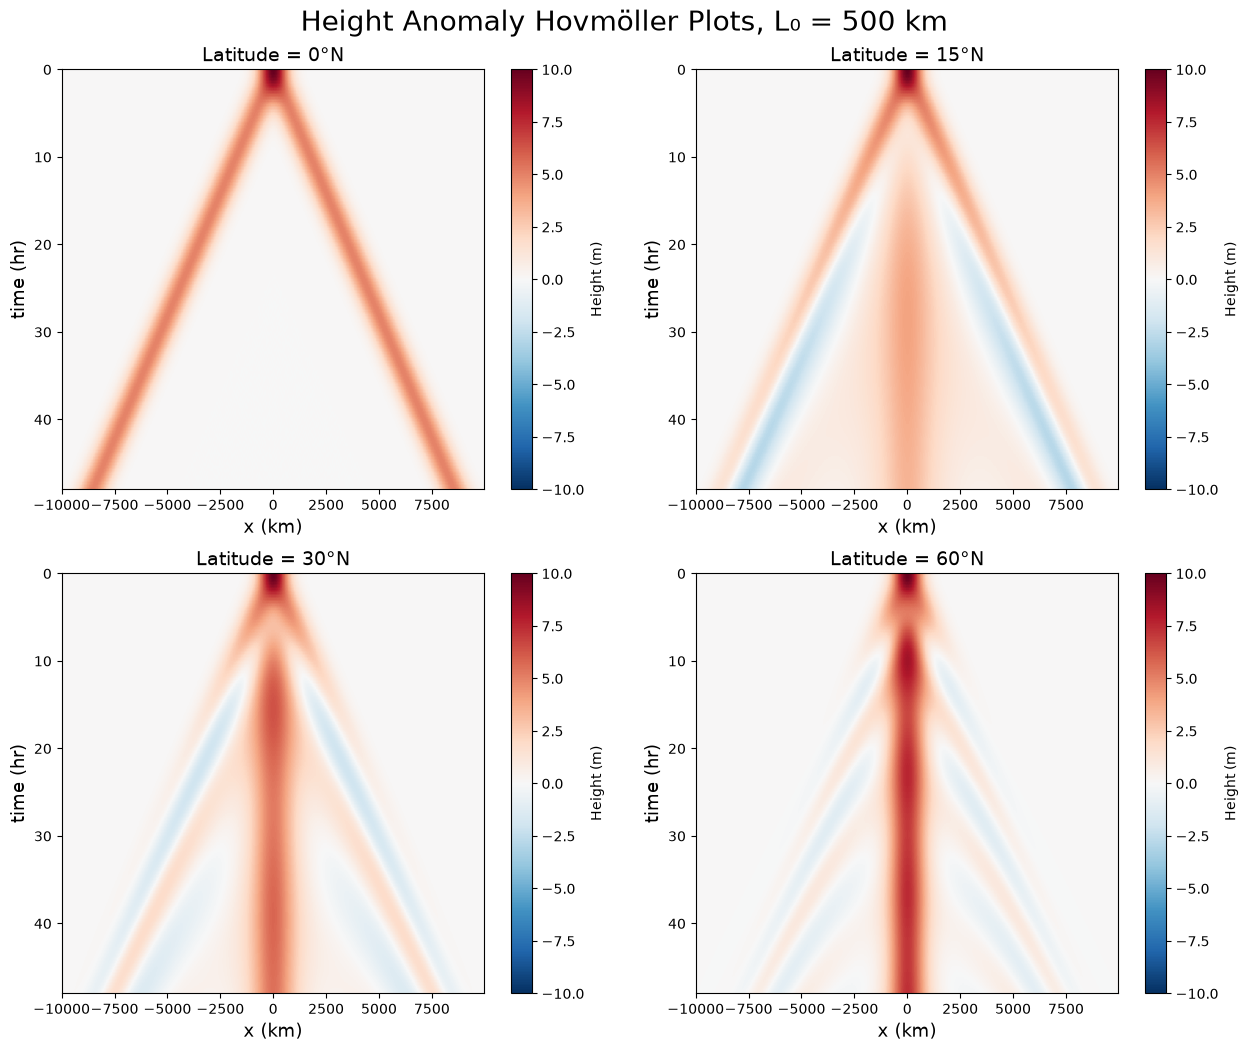

In [114]:
plt.figure()

norm=TwoSlopeNorm(0)

fig, axes = plt.subplots(2, 2, figsize=(15, 12),sharex=False, sharey=False)
#fig.subplots_adjust(right=0.8)
axes[1,0].set_xlabel('x (km)', fontsize=13)
axes[0,0].set_xlabel('x (km)', fontsize=13)
axes[0,1].set_xlabel('x (km)', fontsize=13)
axes[1,1].set_xlabel('x (km)', fontsize=13)
axes[1,0].set_ylabel('time (hr)', fontsize=13)
axes[0,0].set_ylabel('time (hr)', fontsize=13)
axes[0,1].set_ylabel('time (hr)', fontsize=13)
axes[1,1].set_ylabel('time (hr)', fontsize=13)
axes[0,0].invert_yaxis()
axes[0,1].invert_yaxis()
axes[1,0].invert_yaxis()
axes[1,1].invert_yaxis()

bs= axes[0,0].pcolormesh( runs["0°N, L_0=500.0 km"]["x"]/1000, runs["0°N, L_0=500.0 km"]["time"]/3600, runs["0°N, L_0=500.0 km"]["h"][:-1, :-1],cmap="RdBu_r", vmin=-10, vmax=10)
axes[0,0].set_title("Latitude = 0°N",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[0, 0])
cbar.set_label('Height (m)')

#bs.grid()
bs= axes[0,1].pcolormesh( runs["15.0°N, L_0=500.0 km"]["x"]/1000, runs["15.0°N, L_0=500.0 km"]["time"]/3600, runs["15.0°N, L_0=500.0 km"]["h"][:-1, :-1], cmap="RdBu_r", vmin=-10, vmax=10)
axes[0,1].set_title("Latitude = 15°N",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[0, 1])
cbar.set_label('Height (m)')

bs= axes[1,0].pcolormesh( runs["30.0°N, L_0=500.0 km"]["x"]/1000, runs["30.0°N, L_0=500.0 km"]["time"]/3600, runs["30.0°N, L_0=500.0 km"]["h"][:-1, :-1], cmap="RdBu_r", vmin=-10, vmax=10)
axes[1,0].set_title("Latitude = 30°N",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[1, 0])
cbar.set_label('Height (m)')

bs= axes[1,1].pcolormesh( runs["60.0°N, L_0=500.0 km"]["x"]/1000, runs["60.0°N, L_0=500.0 km"]["time"]/3600, runs["60.0°N, L_0=500.0 km"]["h"][:-1, :-1], cmap="RdBu_r", vmin=-10, vmax=10)
axes[1,1].set_title("Latitude = 60°N",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[1, 1])
cbar.set_label('Height (m)')

plt.suptitle("Height Anomaly Hovmöller Plots, L\u2080 = 500 km", fontsize=20, y=0.93)


Text(0.5, 0.93, 'U wind Hovmöller Plots, L₀ = 500 km')

<Figure size 640x480 with 0 Axes>

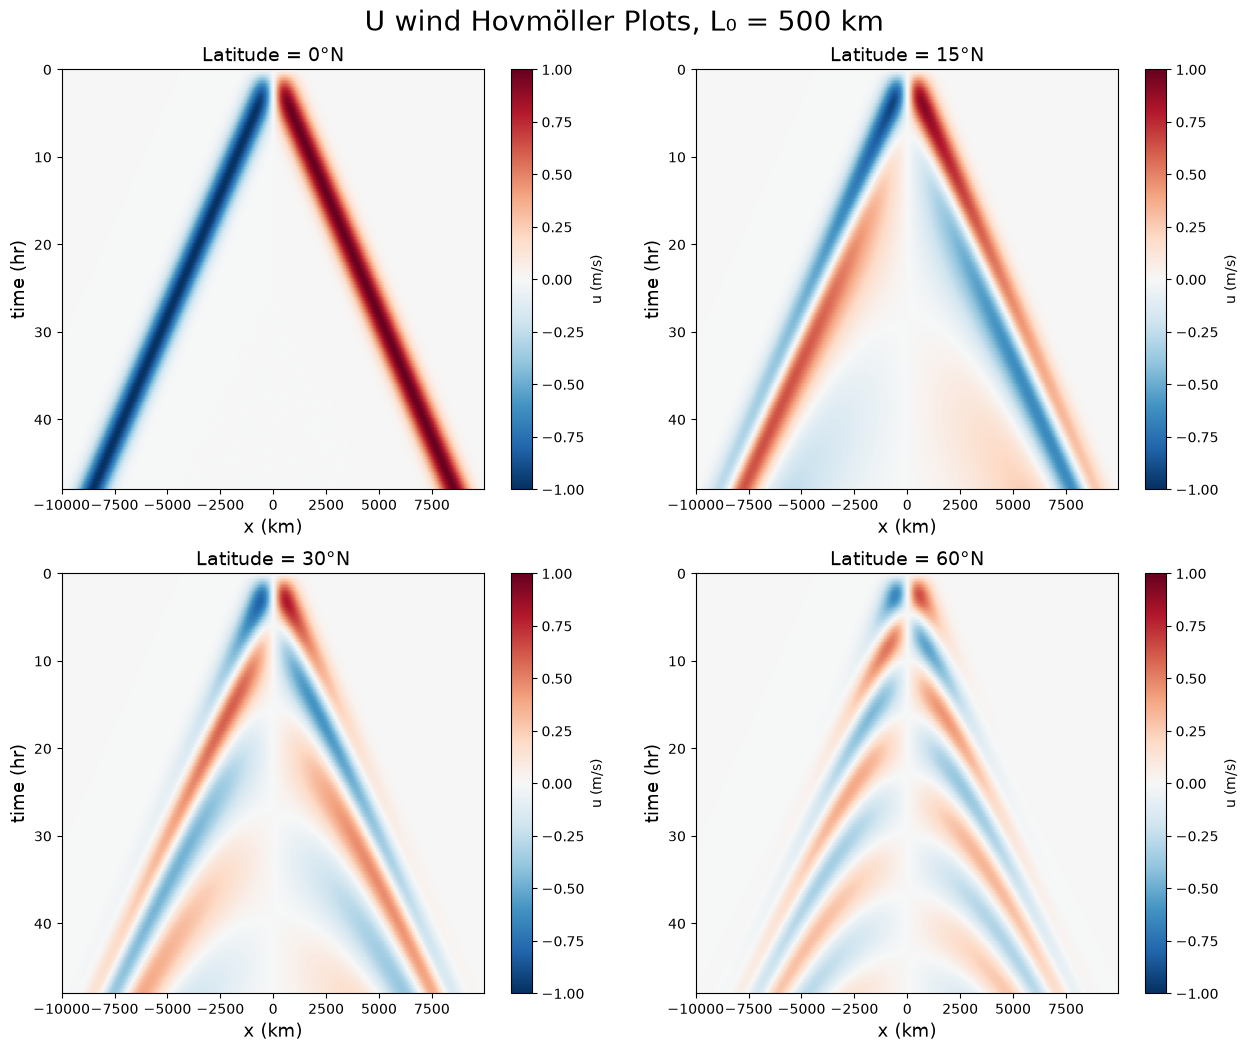

In [115]:
plt.figure()

norm=TwoSlopeNorm(0)

fig, axes = plt.subplots(2, 2, figsize=(15, 12),sharex=False, sharey=False)
#fig.subplots_adjust(right=0.8)
axes[1,0].set_xlabel('x (km)', fontsize=13)
axes[0,0].set_xlabel('x (km)', fontsize=13)
axes[0,1].set_xlabel('x (km)', fontsize=13)
axes[1,1].set_xlabel('x (km)', fontsize=13)
axes[1,0].set_ylabel('time (hr)', fontsize=13)
axes[0,0].set_ylabel('time (hr)', fontsize=13)
axes[0,1].set_ylabel('time (hr)', fontsize=13)
axes[1,1].set_ylabel('time (hr)', fontsize=13)
axes[0,0].invert_yaxis()
axes[0,1].invert_yaxis()
axes[1,0].invert_yaxis()
axes[1,1].invert_yaxis()

bs= axes[0,0].pcolormesh( runs["0°N, L_0=500.0 km"]["x"]/1000, runs["0°N, L_0=500.0 km"]["time"]/3600, runs["0°N, L_0=500.0 km"]["u"][:-1, :-1],cmap="RdBu_r", vmin=-1, vmax=1)
axes[0,0].set_title("Latitude = 0°N",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[0, 0])
cbar.set_label('u (m/s)')

#bs.grid()
bs= axes[0,1].pcolormesh( runs["15.0°N, L_0=500.0 km"]["x"]/1000, runs["15.0°N, L_0=500.0 km"]["time"]/3600, runs["15.0°N, L_0=500.0 km"]["u"][:-1, :-1], cmap="RdBu_r", vmin=-1, vmax=1)
axes[0,1].set_title("Latitude = 15°N",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[0, 1])
cbar.set_label('u (m/s)')

bs= axes[1,0].pcolormesh( runs["30.0°N, L_0=500.0 km"]["x"]/1000, runs["30.0°N, L_0=500.0 km"]["time"]/3600, runs["30.0°N, L_0=500.0 km"]["u"][:-1, :-1], cmap="RdBu_r", vmin=-1, vmax=1)
axes[1,0].set_title("Latitude = 30°N",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[1, 0])
cbar.set_label('u (m/s)')

bs= axes[1,1].pcolormesh( runs["60.0°N, L_0=500.0 km"]["x"]/1000, runs["60.0°N, L_0=500.0 km"]["time"]/3600, runs["60.0°N, L_0=500.0 km"]["u"][:-1, :-1], cmap="RdBu_r", vmin=-1, vmax=1)
axes[1,1].set_title("Latitude = 60°N",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[1, 1])
cbar.set_label('u (m/s)')

plt.suptitle("U wind Hovmöller Plots, L\u2080 = 500 km", fontsize=20, y=0.93)


Text(0.5, 0.93, 'V wind Hovmöller Plots, L₀ = 500 km')

<Figure size 640x480 with 0 Axes>

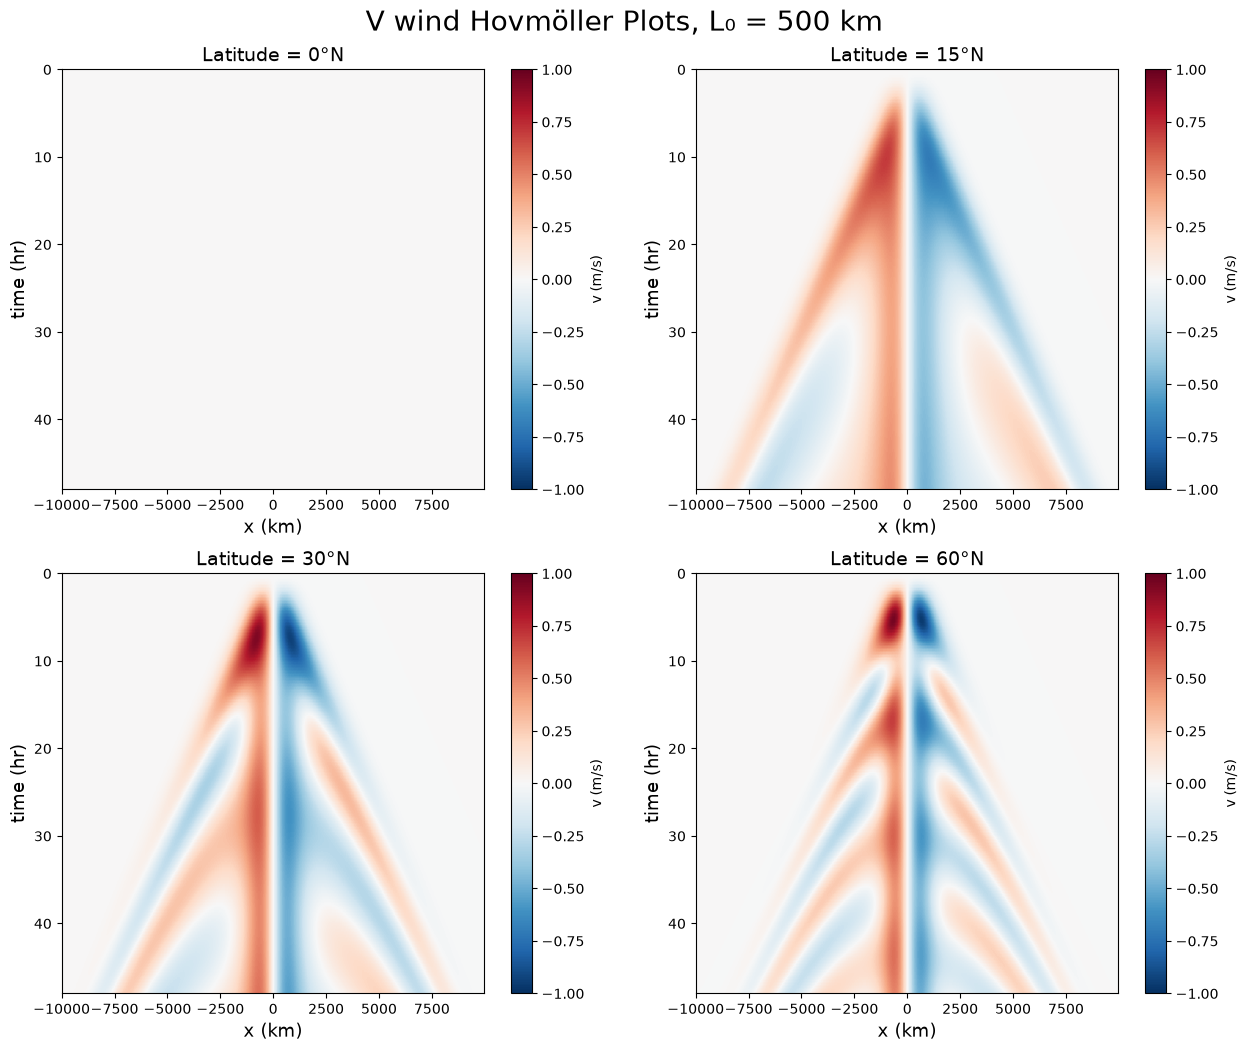

In [116]:
plt.figure()

norm=TwoSlopeNorm(0)

fig, axes = plt.subplots(2, 2, figsize=(15, 12),sharex=False, sharey=False)
#fig.subplots_adjust(right=0.8)
axes[1,0].set_xlabel('x (km)', fontsize=13)
axes[0,0].set_xlabel('x (km)', fontsize=13)
axes[0,1].set_xlabel('x (km)', fontsize=13)
axes[1,1].set_xlabel('x (km)', fontsize=13)
axes[1,0].set_ylabel('time (hr)', fontsize=13)
axes[0,0].set_ylabel('time (hr)', fontsize=13)
axes[0,1].set_ylabel('time (hr)', fontsize=13)
axes[1,1].set_ylabel('time (hr)', fontsize=13)
axes[0,0].invert_yaxis()
axes[0,1].invert_yaxis()
axes[1,0].invert_yaxis()
axes[1,1].invert_yaxis()

bs= axes[0,0].pcolormesh( runs["0°N, L_0=500.0 km"]["x"]/1000, runs["0°N, L_0=500.0 km"]["time"]/3600, runs["0°N, L_0=500.0 km"]["v"][:-1, :-1],cmap="RdBu_r", vmin=-1, vmax=1)
axes[0,0].set_title("Latitude = 0°N",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[0, 0])
cbar.set_label('v (m/s)')

#bs.grid()
bs= axes[0,1].pcolormesh( runs["15.0°N, L_0=500.0 km"]["x"]/1000, runs["15.0°N, L_0=500.0 km"]["time"]/3600, runs["15.0°N, L_0=500.0 km"]["v"][:-1, :-1], cmap="RdBu_r", vmin=-1, vmax=1)
axes[0,1].set_title("Latitude = 15°N",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[0, 1])
cbar.set_label('v (m/s)')

bs= axes[1,0].pcolormesh( runs["30.0°N, L_0=500.0 km"]["x"]/1000, runs["30.0°N, L_0=500.0 km"]["time"]/3600, runs["30.0°N, L_0=500.0 km"]["v"][:-1, :-1], cmap="RdBu_r", vmin=-1, vmax=1)
axes[1,0].set_title("Latitude = 30°N",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[1, 0])
cbar.set_label('v (m/s)')

bs= axes[1,1].pcolormesh( runs["60.0°N, L_0=500.0 km"]["x"]/1000, runs["60.0°N, L_0=500.0 km"]["time"]/3600, runs["60.0°N, L_0=500.0 km"]["v"][:-1, :-1], cmap="RdBu_r", vmin=-1, vmax=1)
axes[1,1].set_title("Latitude = 60°N",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[1, 1])
cbar.set_label('v (m/s)')

plt.suptitle("V wind Hovmöller Plots, L\u2080 = 500 km", fontsize=20, y=0.93)


Text(0.5, 0.93, 'Total wind Hovmöller Plots, L₀ = 500 km')

<Figure size 640x480 with 0 Axes>

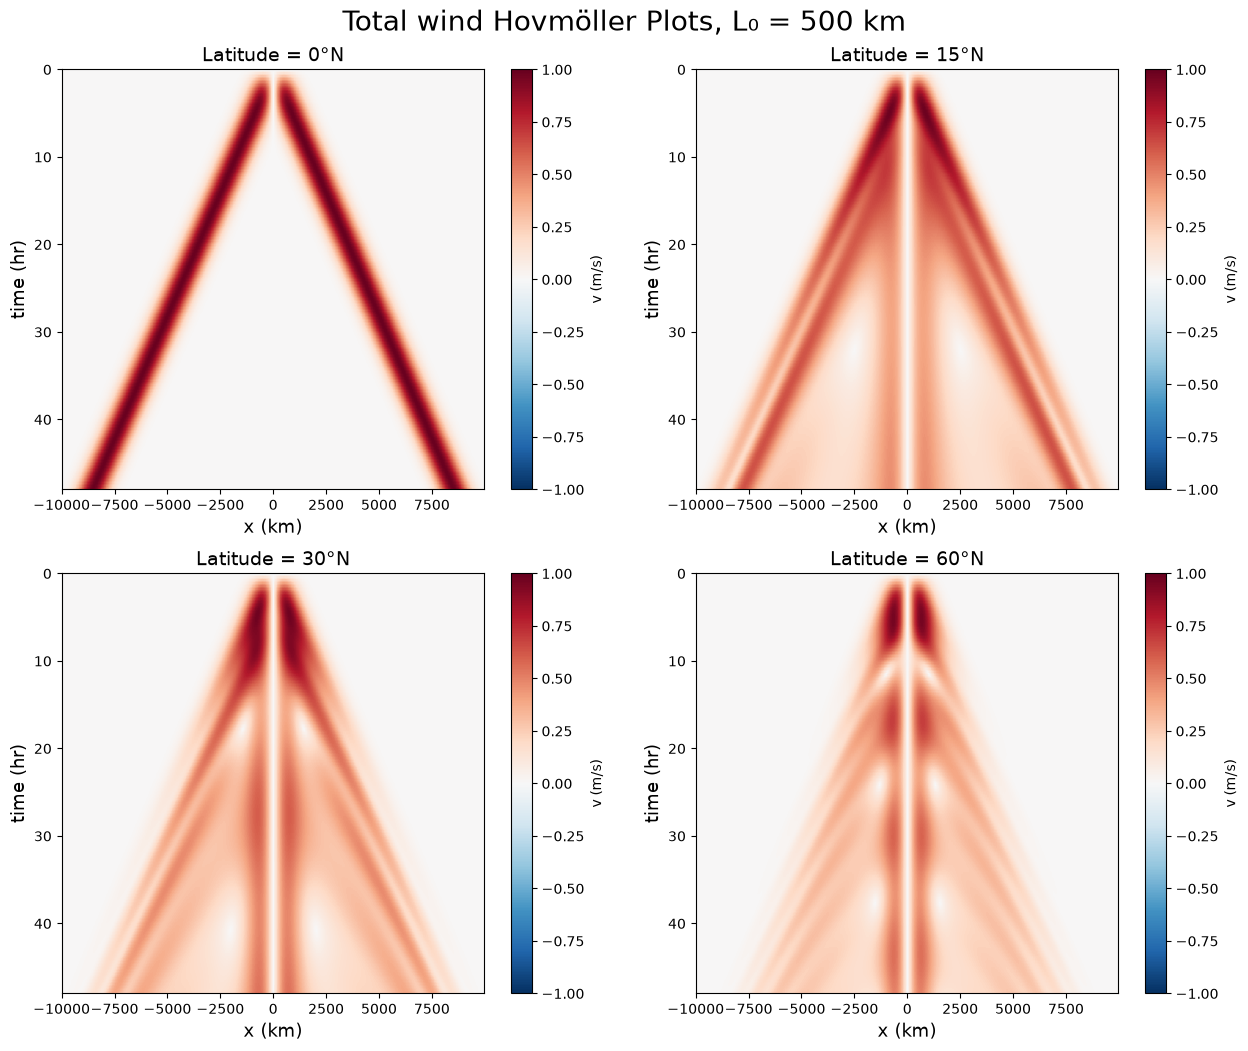

In [140]:
plt.figure()

norm=TwoSlopeNorm(0)

fig, axes = plt.subplots(2, 2, figsize=(15, 12),sharex=False, sharey=False)
#fig.subplots_adjust(right=0.8)
axes[1,0].set_xlabel('x (km)', fontsize=13)
axes[0,0].set_xlabel('x (km)', fontsize=13)
axes[0,1].set_xlabel('x (km)', fontsize=13)
axes[1,1].set_xlabel('x (km)', fontsize=13)
axes[1,0].set_ylabel('time (hr)', fontsize=13)
axes[0,0].set_ylabel('time (hr)', fontsize=13)
axes[0,1].set_ylabel('time (hr)', fontsize=13)
axes[1,1].set_ylabel('time (hr)', fontsize=13)
axes[0,0].invert_yaxis()
axes[0,1].invert_yaxis()
axes[1,0].invert_yaxis()
axes[1,1].invert_yaxis()

def total_wind(u_wind,v_wind):
    combined=np.sqrt(((u_wind**2)+(v_wind**2)))
    return(combined)
            


wind1=total_wind(runs["60.0°N, L_0=500.0 km"]["u"][:-1, :-1],runs["60.0°N, L_0=500.0 km"]["v"][:-1, :-1])

bs= axes[1,1].pcolormesh( runs["60.0°N, L_0=500.0 km"]["x"]/1000, runs["60.0°N, L_0=500.0 km"]["time"]/3600, wind1,cmap="RdBu_r", vmin=-1, vmax=1)
axes[1,1].set_title("Latitude = 60°N",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[0, 0])
cbar.set_label('v (m/s)')

wind1=total_wind(runs["0°N, L_0=500.0 km"]["u"][:-1, :-1],runs["0°N, L_0=500.0 km"]["v"][:-1, :-1])
#bs.grid()
bs= axes[0,0].pcolormesh( runs["0°N, L_0=500.0 km"]["x"]/1000, runs["0°N, L_0=500.0 km"]["time"]/3600, wind1, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0,0].set_title("Latitude = 0°N",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[0, 1])
cbar.set_label('v (m/s)')

wind1=total_wind(runs["15.0°N, L_0=500.0 km"]["u"][:-1, :-1],runs["15.0°N, L_0=500.0 km"]["v"][:-1, :-1])
bs= axes[0,1].pcolormesh( runs["15.0°N, L_0=500.0 km"]["x"]/1000, runs["15.0°N, L_0=500.0 km"]["time"]/3600, wind1, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0,1].set_title("Latitude = 15°N",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[1, 0])
cbar.set_label('v (m/s)')

wind1=total_wind(runs["30.0°N, L_0=500.0 km"]["u"][:-1, :-1],runs["30.0°N, L_0=500.0 km"]["v"][:-1, :-1])
bs= axes[1,0].pcolormesh( runs["30.0°N, L_0=500.0 km"]["x"]/1000, runs["30.0°N, L_0=500.0 km"]["time"]/3600, wind1, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1,0].set_title("Latitude = 30°N",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[1, 1])
cbar.set_label('v (m/s)')

plt.suptitle("Total wind Hovmöller Plots, L\u2080 = 500 km", fontsize=20, y=0.93)


Text(0.5, 0.93, 'Height Anomaly Hovmöller Plots, Latitude = 15')

<Figure size 640x480 with 0 Axes>

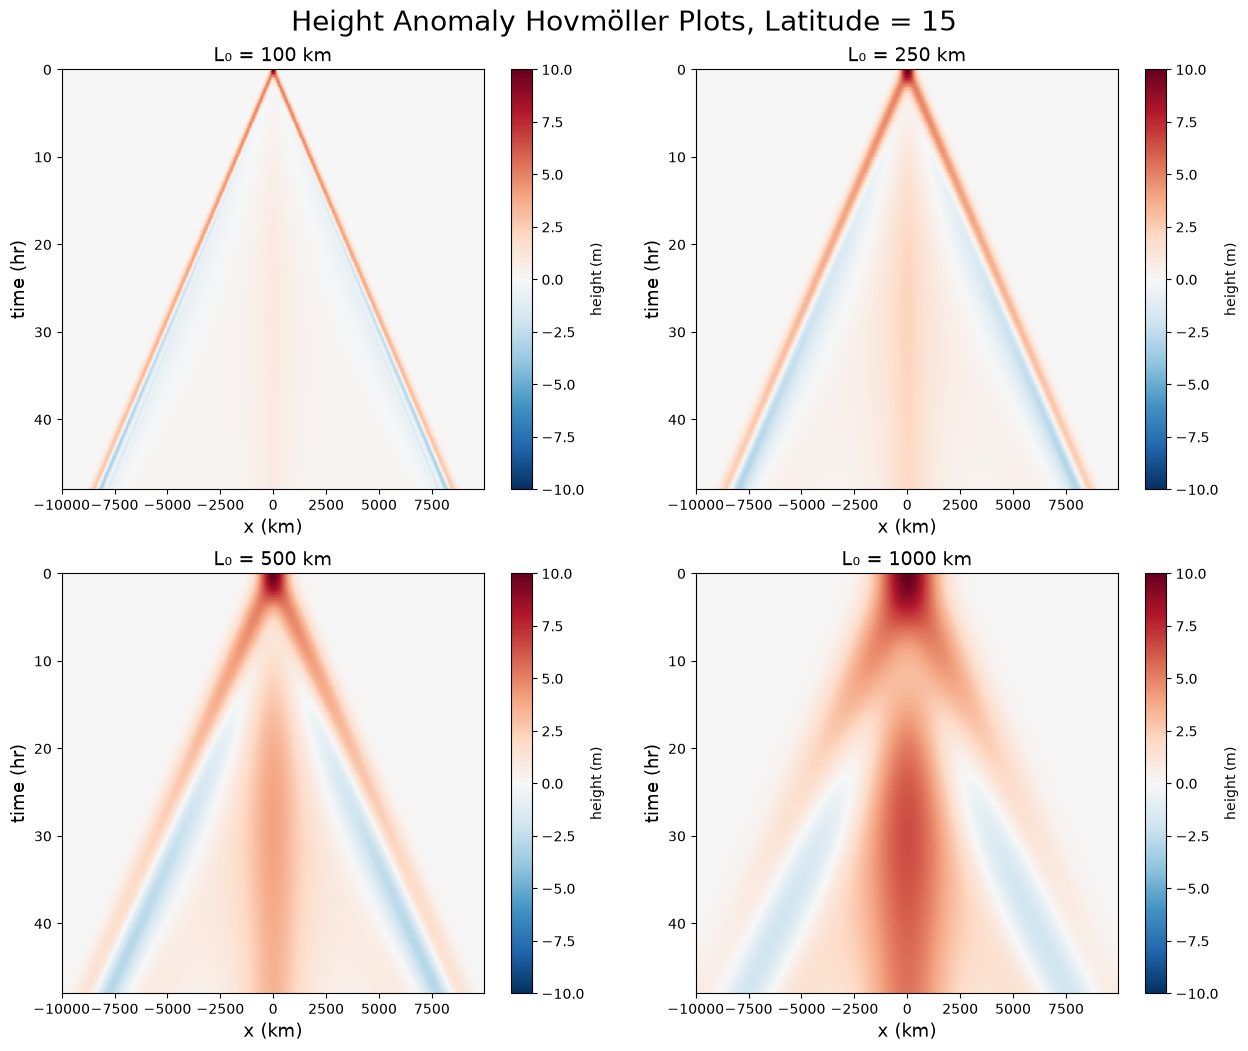

In [139]:
plt.figure()

norm=TwoSlopeNorm(0)

fig, axes = plt.subplots(2, 2, figsize=(15, 12),sharex=False, sharey=False)
#fig.subplots_adjust(right=0.8)
axes[1,0].set_xlabel('x (km)', fontsize=13)
axes[0,0].set_xlabel('x (km)', fontsize=13)
axes[0,1].set_xlabel('x (km)', fontsize=13)
axes[1,1].set_xlabel('x (km)', fontsize=13)
axes[1,0].set_ylabel('time (hr)', fontsize=13)
axes[0,0].set_ylabel('time (hr)', fontsize=13)
axes[0,1].set_ylabel('time (hr)', fontsize=13)
axes[1,1].set_ylabel('time (hr)', fontsize=13)
axes[0,0].invert_yaxis()
axes[0,1].invert_yaxis()
axes[1,0].invert_yaxis()
axes[1,1].invert_yaxis()

bs= axes[1,1].pcolormesh( runs["15.0°N, L_0=1000 km"]["x"]/1000, runs["15.0°N, L_0=1000 km"]["time"]/3600, runs["15.0°N, L_0=1000 km"]["h"][:-1, :-1],cmap="RdBu_r", vmin=-10, vmax=10)
axes[1,1].set_title("L\u2080 = 1000 km",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[0, 0])
cbar.set_label('height (m)')

#bs.grid()
bs= axes[0,0].pcolormesh( runs["15.0°N, L_0=100 km"]["x"]/1000, runs["15.0°N, L_0=100 km"]["time"]/3600, runs["15.0°N, L_0=100 km"]["h"][:-1, :-1], cmap="RdBu_r", vmin=-10, vmax=10)
axes[0,0].set_title("L\u2080 = 100 km",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[0, 1])
cbar.set_label('height (m)')

bs= axes[0,1].pcolormesh( runs["15.0°N, L_0=250 km"]["x"]/1000, runs["15.0°N, L_0=250 km"]["time"]/3600, runs["15.0°N, L_0=250 km"]["h"][:-1, :-1], cmap="RdBu_r", vmin=-10, vmax=10)
axes[0,1].set_title("L\u2080 = 250 km",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[1, 0])
cbar.set_label('height (m)')

bs= axes[1,0].pcolormesh( runs["15.0°N, L_0=500 km"]["x"]/1000, runs["15.0°N, L_0=500 km"]["time"]/3600, runs["15.0°N, L_0=500 km"]["h"][:-1, :-1], cmap="RdBu_r", vmin=-10, vmax=10)
axes[1,0].set_title("L\u2080 = 500 km",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[1, 1])
cbar.set_label('height (m)')

plt.suptitle("Height Anomaly Hovmöller Plots, Latitude = 15°N", fontsize=20, y=0.93)


Text(0.5, 0.93, 'U wind Hovmöller Plots, Latitude = 15°N')

<Figure size 640x480 with 0 Axes>

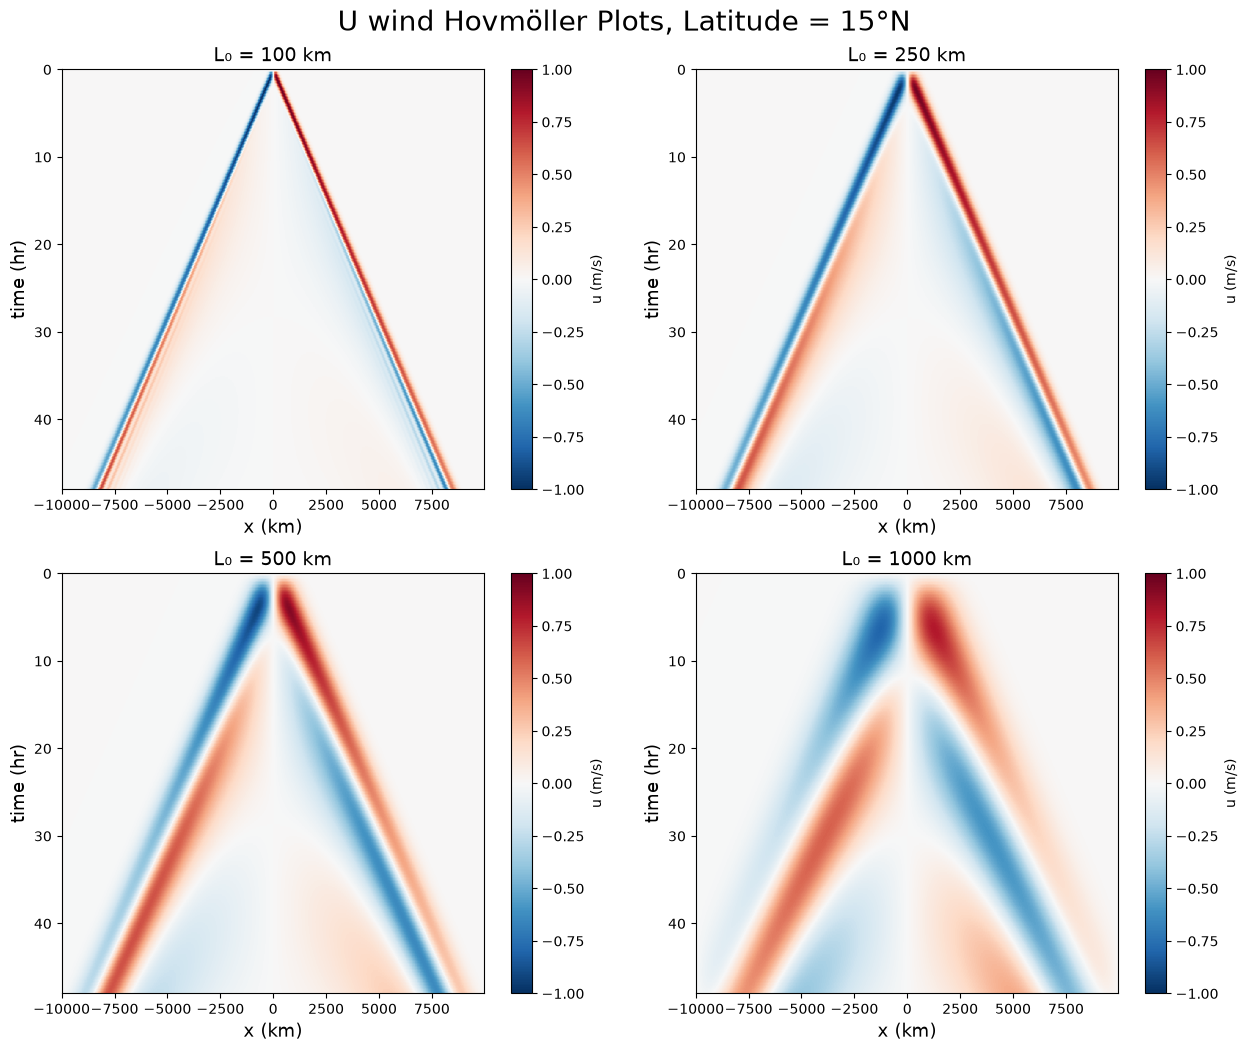

In [118]:
plt.figure()

norm=TwoSlopeNorm(0)

fig, axes = plt.subplots(2, 2, figsize=(15, 12),sharex=False, sharey=False)
#fig.subplots_adjust(right=0.8)
axes[1,0].set_xlabel('x (km)', fontsize=13)
axes[0,0].set_xlabel('x (km)', fontsize=13)
axes[0,1].set_xlabel('x (km)', fontsize=13)
axes[1,1].set_xlabel('x (km)', fontsize=13)
axes[1,0].set_ylabel('time (hr)', fontsize=13)
axes[0,0].set_ylabel('time (hr)', fontsize=13)
axes[0,1].set_ylabel('time (hr)', fontsize=13)
axes[1,1].set_ylabel('time (hr)', fontsize=13)
axes[0,0].invert_yaxis()
axes[0,1].invert_yaxis()
axes[1,0].invert_yaxis()
axes[1,1].invert_yaxis()

bs= axes[1,1].pcolormesh( runs["15.0°N, L_0=1000 km"]["x"]/1000, runs["15.0°N, L_0=1000 km"]["time"]/3600, runs["15.0°N, L_0=1000 km"]["u"][:-1, :-1],cmap="RdBu_r", vmin=-1, vmax=1)
axes[1,1].set_title("L\u2080 = 1000 km",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[0, 0])
cbar.set_label('u (m/s)')

#bs.grid()
bs= axes[0,0].pcolormesh( runs["15.0°N, L_0=100 km"]["x"]/1000, runs["15.0°N, L_0=100 km"]["time"]/3600, runs["15.0°N, L_0=100 km"]["u"][:-1, :-1], cmap="RdBu_r", vmin=-1, vmax=1)
axes[0,0].set_title("L\u2080 = 100 km",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[0, 1])
cbar.set_label('u (m/s)')

bs= axes[0,1].pcolormesh( runs["15.0°N, L_0=250 km"]["x"]/1000, runs["15.0°N, L_0=250 km"]["time"]/3600, runs["15.0°N, L_0=250 km"]["u"][:-1, :-1], cmap="RdBu_r", vmin=-1, vmax=1)
axes[0,1].set_title("L\u2080 = 250 km",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[1, 0])
cbar.set_label('u (m/s)')

bs= axes[1,0].pcolormesh( runs["15.0°N, L_0=500 km"]["x"]/1000, runs["15.0°N, L_0=500 km"]["time"]/3600, runs["15.0°N, L_0=500 km"]["u"][:-1, :-1], cmap="RdBu_r", vmin=-1, vmax=1)
axes[1,0].set_title("L\u2080 = 500 km",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[1, 1])
cbar.set_label('u (m/s)')

plt.suptitle("U wind Hovmöller Plots, Latitude = 15°N", fontsize=20, y=0.93)


Text(0.5, 0.93, 'V wind Hovmöller Plots, Latitude = 15°N')

<Figure size 640x480 with 0 Axes>

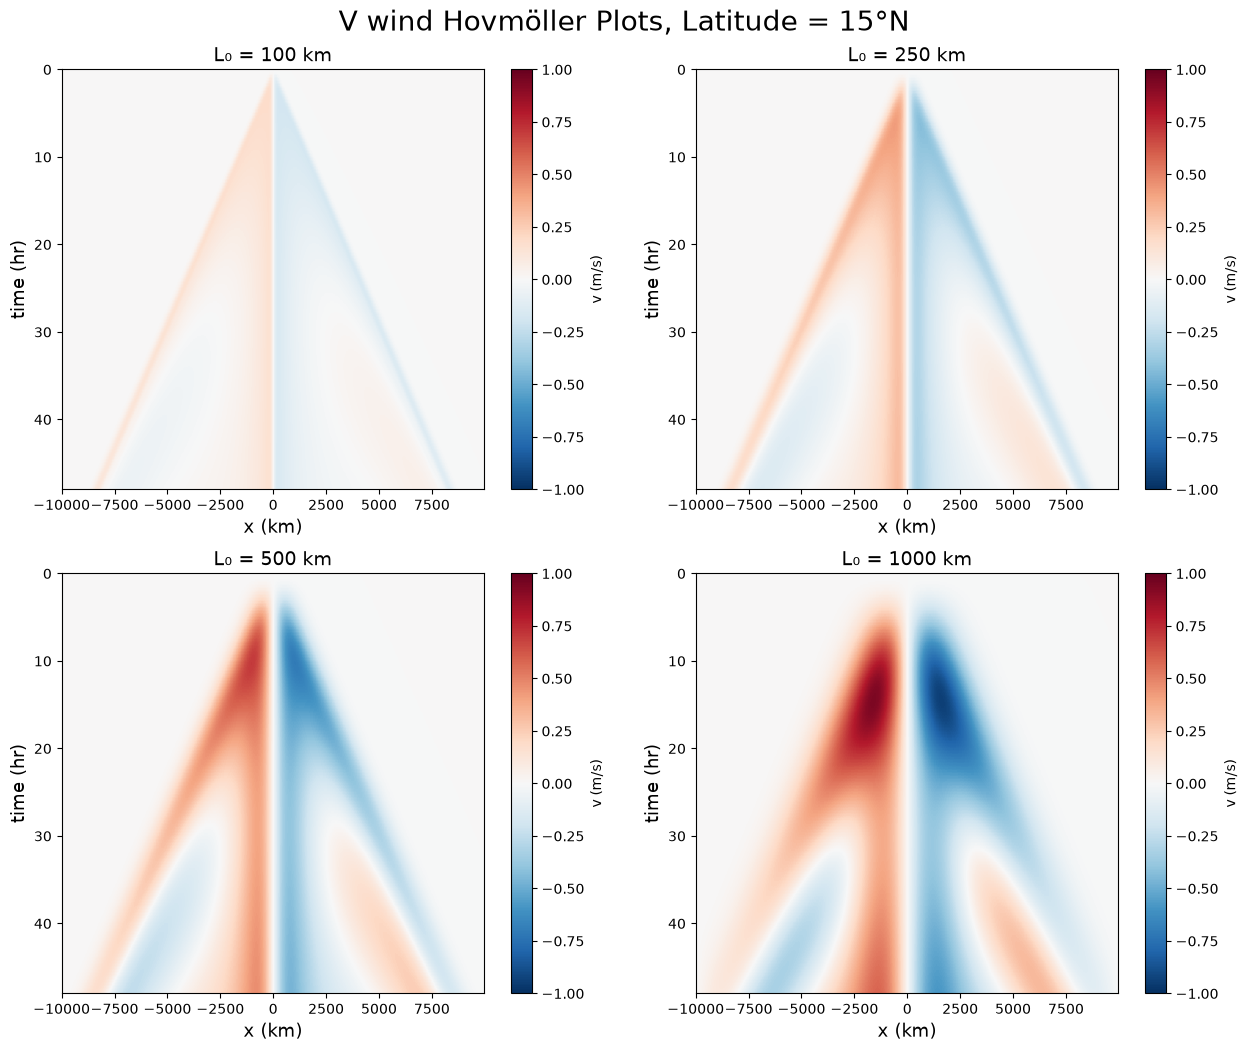

In [168]:
plt.figure()

norm=TwoSlopeNorm(0)

fig, axes = plt.subplots(2, 2, figsize=(15, 12),sharex=False, sharey=False)
#fig.subplots_adjust(right=0.8)
axes[1,0].set_xlabel('x (km)', fontsize=13)
axes[0,0].set_xlabel('x (km)', fontsize=13)
axes[0,1].set_xlabel('x (km)', fontsize=13)
axes[1,1].set_xlabel('x (km)', fontsize=13)
axes[1,0].set_ylabel('time (hr)', fontsize=13)
axes[0,0].set_ylabel('time (hr)', fontsize=13)
axes[0,1].set_ylabel('time (hr)', fontsize=13)
axes[1,1].set_ylabel('time (hr)', fontsize=13)
axes[0,0].invert_yaxis()
axes[0,1].invert_yaxis()
axes[1,0].invert_yaxis()
axes[1,1].invert_yaxis()

bs= axes[1,1].pcolormesh( runs["15.0°N, L_0=1000 km"]["x"]/1000, runs["15.0°N, L_0=1000 km"]["time"]/3600, runs["15.0°N, L_0=1000 km"]["v"][:-1, :-1],cmap="RdBu_r", vmin=-1, vmax=1)
axes[1,1].set_title("L\u2080 = 1000 km",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[0, 0])
cbar.set_label('v (m/s)')

#bs.grid()
bs= axes[0,0].pcolormesh( runs["15.0°N, L_0=100 km"]["x"]/1000, runs["15.0°N, L_0=100 km"]["time"]/3600, runs["15.0°N, L_0=100 km"]["v"][:-1, :-1], cmap="RdBu_r", vmin=-1, vmax=1)
axes[0,0].set_title("L\u2080 = 100 km",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[0, 1])
cbar.set_label('v (m/s)')

bs= axes[0,1].pcolormesh( runs["15.0°N, L_0=250 km"]["x"]/1000, runs["15.0°N, L_0=250 km"]["time"]/3600, runs["15.0°N, L_0=250 km"]["v"][:-1, :-1], cmap="RdBu_r", vmin=-1, vmax=1)
axes[0,1].set_title("L\u2080 = 250 km",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[1, 0])
cbar.set_label('v (m/s)')

bs= axes[1,0].pcolormesh( runs["15.0°N, L_0=500 km"]["x"]/1000, runs["15.0°N, L_0=500 km"]["time"]/3600, runs["15.0°N, L_0=500 km"]["v"][:-1, :-1], cmap="RdBu_r", vmin=-1, vmax=1)
axes[1,0].set_title("L\u2080 = 500 km",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[1, 1])
cbar.set_label('v (m/s)')

plt.suptitle("V wind Hovmöller Plots, Latitude = 15°N", fontsize=20, y=0.93)


In [128]:
print(type(runs["15.0°N, L_0=500 km"]["v"][:-1, :-1]))
#runs["15.0°N, L_0=500 km"]["v"][:-1, :-1]**2
#print((runs["15.0°N, L_0=500 km"]["v"][:-1, :-1]**2) + (runs["15.0°N, L_0=500 km"]["u"][:-1, :-1]**2))
np.sqrt((runs["15.0°N, L_0=500 km"]["v"][:-1, :-1]**2) + (runs["15.0°N, L_0=500 km"]["u"][:-1, :-1]**2))

<class 'numpy.ndarray'>


array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 9.63844980e-87, 2.29838749e-86, ...,
        1.13623026e-85, 5.15098779e-86, 2.29838749e-86],
       [0.00000000e+00, 3.39863389e-86, 8.86486637e-86, ...,
        4.44254465e-85, 2.01424017e-85, 8.86486637e-86],
       ...,
       [0.00000000e+00, 1.55671594e-03, 3.12639303e-03, ...,
        6.35645558e-03, 4.72198929e-03, 3.12639303e-03],
       [0.00000000e+00, 1.80148010e-03, 3.61695688e-03, ...,
        7.34580056e-03, 5.46041272e-03, 3.61695688e-03],
       [0.00000000e+00, 2.07621298e-03, 4.16741836e-03, ...,
        8.45461095e-03, 6.28858118e-03, 4.16741836e-03]], shape=(288, 999))

Text(0.5, 0.93, 'Total wind Hovmöller Plots, Latitude = 15°N')

<Figure size 640x480 with 0 Axes>

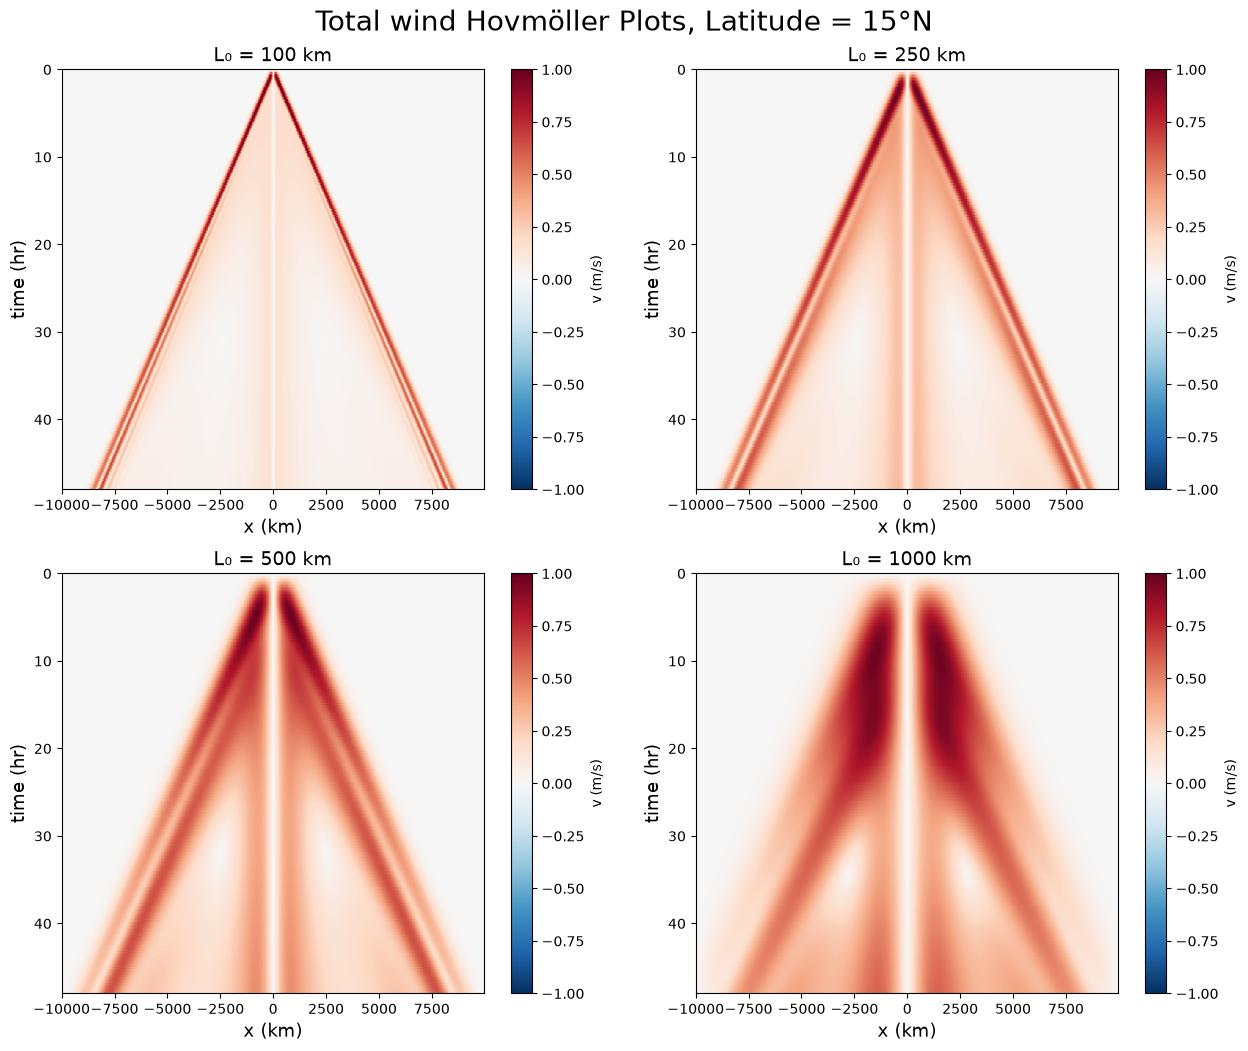

In [136]:
plt.figure()

norm=TwoSlopeNorm(0)

fig, axes = plt.subplots(2, 2, figsize=(15, 12),sharex=False, sharey=False)
#fig.subplots_adjust(right=0.8)
axes[1,0].set_xlabel('x (km)', fontsize=13)
axes[0,0].set_xlabel('x (km)', fontsize=13)
axes[0,1].set_xlabel('x (km)', fontsize=13)
axes[1,1].set_xlabel('x (km)', fontsize=13)
axes[1,0].set_ylabel('time (hr)', fontsize=13)
axes[0,0].set_ylabel('time (hr)', fontsize=13)
axes[0,1].set_ylabel('time (hr)', fontsize=13)
axes[1,1].set_ylabel('time (hr)', fontsize=13)
axes[0,0].invert_yaxis()
axes[0,1].invert_yaxis()
axes[1,0].invert_yaxis()
axes[1,1].invert_yaxis()

def total_wind(u_wind,v_wind):
    combined=np.sqrt(((u_wind**2)+(v_wind**2)))
    return(combined)
            


wind1=total_wind(runs["15.0°N, L_0=1000 km"]["u"][:-1, :-1],runs["15.0°N, L_0=1000 km"]["v"][:-1, :-1])

bs= axes[1,1].pcolormesh( runs["15.0°N, L_0=1000 km"]["x"]/1000, runs["15.0°N, L_0=1000 km"]["time"]/3600, wind1,cmap="RdBu_r", vmin=-1, vmax=1)
axes[1,1].set_title("L\u2080 = 1000 km",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[0, 0])
cbar.set_label('v (m/s)')

wind1=total_wind(runs["15.0°N, L_0=100 km"]["u"][:-1, :-1],runs["15.0°N, L_0=100 km"]["v"][:-1, :-1])
#bs.grid()
bs= axes[0,0].pcolormesh( runs["15.0°N, L_0=100 km"]["x"]/1000, runs["15.0°N, L_0=100 km"]["time"]/3600, wind1, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0,0].set_title("L\u2080 = 100 km",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[0, 1])
cbar.set_label('v (m/s)')

wind1=total_wind(runs["15.0°N, L_0=250 km"]["u"][:-1, :-1],runs["15.0°N, L_0=250 km"]["v"][:-1, :-1])
bs= axes[0,1].pcolormesh( runs["15.0°N, L_0=250 km"]["x"]/1000, runs["15.0°N, L_0=250 km"]["time"]/3600, wind1, cmap="RdBu_r", vmin=-1, vmax=1)
axes[0,1].set_title("L\u2080 = 250 km",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[1, 0])
cbar.set_label('v (m/s)')

wind1=total_wind(runs["15.0°N, L_0=500 km"]["u"][:-1, :-1],runs["15.0°N, L_0=500 km"]["v"][:-1, :-1])
bs= axes[1,0].pcolormesh( runs["15.0°N, L_0=500 km"]["x"]/1000, runs["15.0°N, L_0=500 km"]["time"]/3600, wind1, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1,0].set_title("L\u2080 = 500 km",fontsize=14)
cbar=plt.colorbar(bs, ax=axes[1, 1])
cbar.set_label('v (m/s)')

plt.suptitle("Total wind Hovmöller Plots, Latitude = 15°N", fontsize=20, y=0.93)


(289, 1000)
(289, 1000)
(289, 1000)
(289, 1000)


Text(0.5, 0.93, 'Height Anomaly Plots, L₀ = 500 km')

<Figure size 640x480 with 0 Axes>

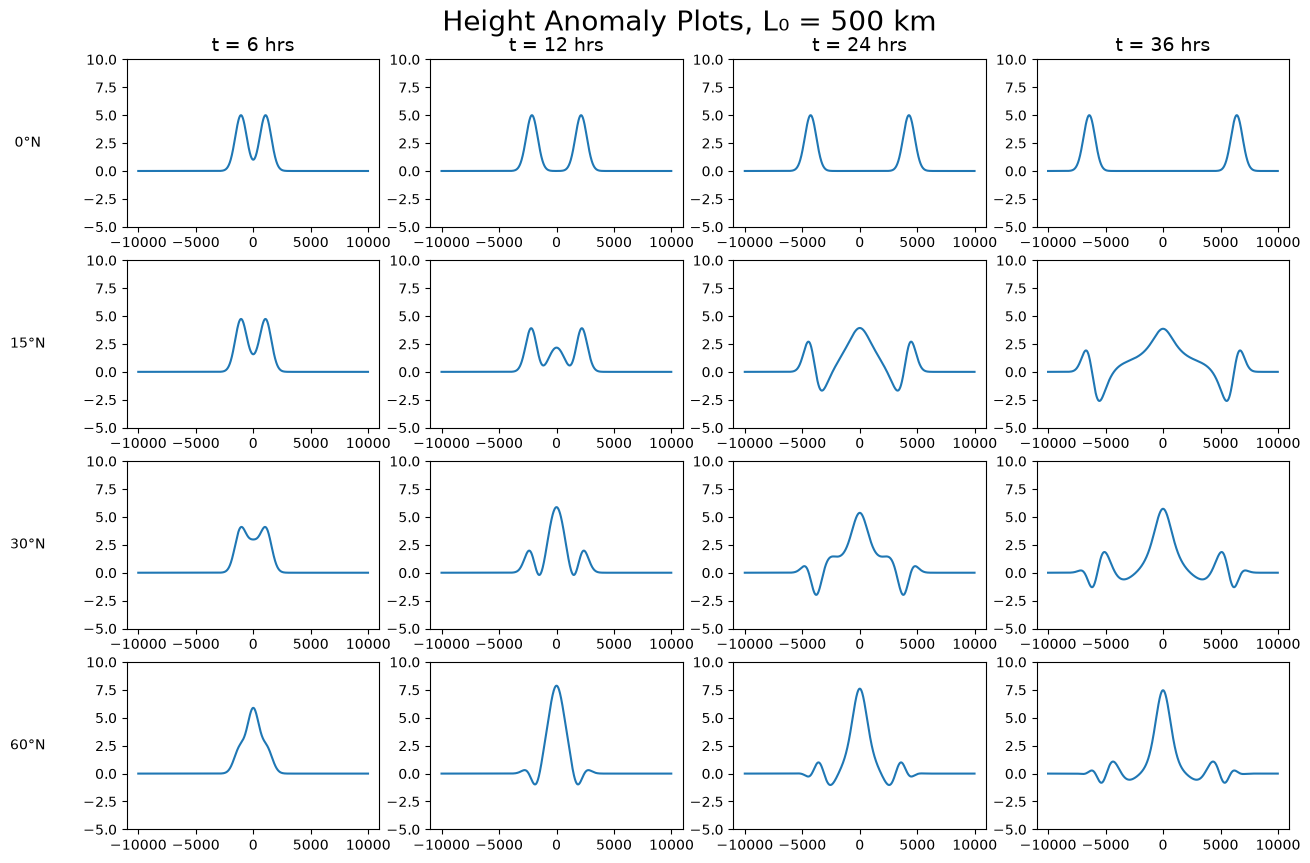

In [165]:
# 4 lats & 4 timesteps (6 hr, 12 hr, 24 hr, 36hr)

plt.figure()
fig, axes = plt.subplots(4, 4, figsize=(15, 10),sharex=False, sharey=False)

for case_index in list(range(0,4)):
    case=case_names[case_index]
    u=runs[case]["u"]
    v=runs[case]["v"]
    x=runs[case]["x"]
    h=runs[case]["h"]
    f_0=runs[case]["f_0"]
    l_0=runs[case]["width"]
    print(h.shape)
    time=runs[case]["time"]
    bs= axes[case_index,0].plot(x/1000,h[(6*6),:])
    axes[case_index,0].set_ylim([-5, 10])
    axes[case_index,1].set_ylim([-5, 10])
    axes[case_index,2].set_ylim([-5, 10])
    axes[case_index,3].set_ylim([-5, 10])
    axes[0,0].set_title("t = 6 hrs",fontsize=14)
    axes[0,1].set_title("t = 12 hrs",fontsize=14)
    axes[0,2].set_title("t = 24 hrs",fontsize=14)
    axes[0,3].set_title("t = 36 hrs",fontsize=14)
    lat=round(np.rad2deg(np.arcsin(f_0/(2*(OMEGA)))))
    axes[case_index,0].set_ylabel(str(lat)+"°N", rotation=0, labelpad=40, verticalalignment='center')
    bs= axes[case_index,1].plot(x/1000,h[(12*6),:])
    bs= axes[case_index,2].plot(x/1000,h[24*6,:])
    bs= axes[case_index,3].plot(x/1000,h[36*6,:])

plt.suptitle("Height Anomaly Plots, L\u2080 = 500 km", fontsize=20, y=0.93)


(289, 1000)
(289, 1000)
(289, 1000)
(289, 1000)


Text(0.5, 0.93, 'u wind Anomaly Plots, L₀ = 500 km')

<Figure size 640x480 with 0 Axes>

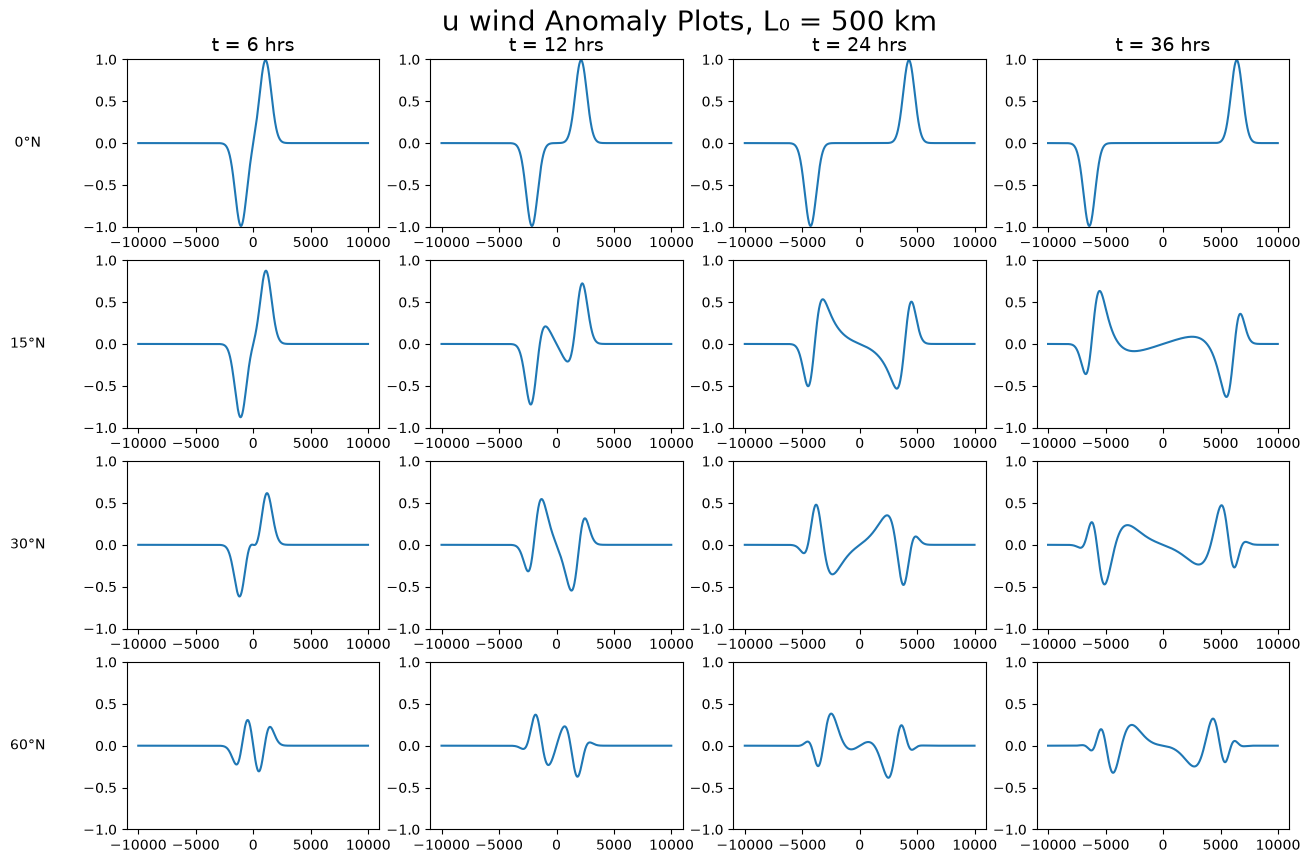

In [166]:
# 4 lats & 4 timesteps (6 hr, 12 hr, 24 hr, 36hr)

plt.figure()
fig, axes = plt.subplots(4, 4, figsize=(15, 10),sharex=False, sharey=False)

for case_index in list(range(0,4)):
    case=case_names[case_index]
    u=runs[case]["u"]
    v=runs[case]["v"]
    x=runs[case]["x"]
    h=runs[case]["h"]
    f_0=runs[case]["f_0"]
    l_0=runs[case]["width"]
    print(h.shape)
    time=runs[case]["time"]
    bs= axes[case_index,0].plot(x/1000,u[(6*6),:])
    axes[case_index,0].set_ylim([-1, 1])
    axes[case_index,1].set_ylim([-1, 1])
    axes[case_index,2].set_ylim([-1, 1])
    axes[case_index,3].set_ylim([-1, 1])
    axes[0,0].set_title("t = 6 hrs",fontsize=14)
    axes[0,1].set_title("t = 12 hrs",fontsize=14)
    axes[0,2].set_title("t = 24 hrs",fontsize=14)
    axes[0,3].set_title("t = 36 hrs",fontsize=14)
    lat=round(np.rad2deg(np.arcsin(f_0/(2*(OMEGA)))))
    axes[case_index,0].set_ylabel(str(lat)+"°N", rotation=0, labelpad=40, verticalalignment='center')
    bs= axes[case_index,1].plot(x/1000,u[(12*6),:])
    bs= axes[case_index,2].plot(x/1000,u[24*6,:])
    bs= axes[case_index,3].plot(x/1000,u[36*6,:])

plt.suptitle("u wind Anomaly Plots, L\u2080 = 500 km", fontsize=20, y=0.93)


(289, 1000)
(289, 1000)
(289, 1000)
(289, 1000)


Text(0.5, 0.93, 'v wind Anomaly Plots, L₀ = 500 km')

<Figure size 640x480 with 0 Axes>

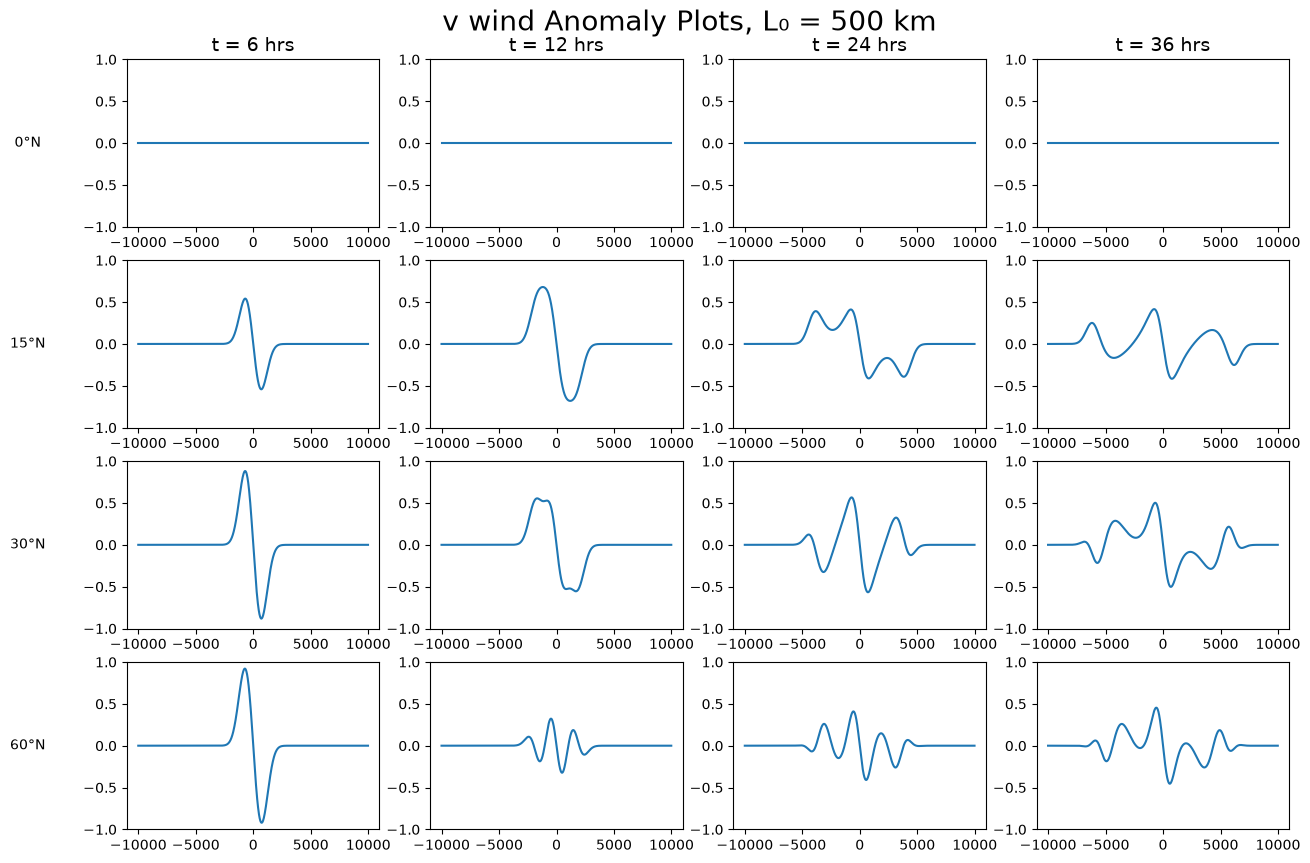

In [167]:
# 4 lats & 4 timesteps (6 hr, 12 hr, 24 hr, 36hr)

plt.figure()
fig, axes = plt.subplots(4, 4, figsize=(15, 10),sharex=False, sharey=False)

for case_index in list(range(0,4)):
    case=case_names[case_index]
    u=runs[case]["u"]
    v=runs[case]["v"]
    x=runs[case]["x"]
    h=runs[case]["h"]
    f_0=runs[case]["f_0"]
    l_0=runs[case]["width"]
    print(h.shape)
    time=runs[case]["time"]
    bs= axes[case_index,0].plot(x/1000,v[(6*6),:])
    axes[0,0].set_title("t = 6 hrs",fontsize=14)
    axes[0,1].set_title("t = 12 hrs",fontsize=14)
    axes[0,2].set_title("t = 24 hrs",fontsize=14)
    axes[0,3].set_title("t = 36 hrs",fontsize=14)
    axes[case_index,0].set_ylim([-1, 1])
    axes[case_index,1].set_ylim([-1, 1])
    axes[case_index,2].set_ylim([-1, 1])
    axes[case_index,3].set_ylim([-1, 1])
    lat=round(np.rad2deg(np.arcsin(f_0/(2*(OMEGA)))))
    axes[case_index,0].set_ylabel(str(lat)+"°N", rotation=0, labelpad=40, verticalalignment='center')
    bs= axes[case_index,1].plot(x/1000,v[(12*6),:])
    bs= axes[case_index,2].plot(x/1000,v[24*6,:])
    bs= axes[case_index,3].plot(x/1000,v[36*6,:])

plt.suptitle("v wind Anomaly Plots, L\u2080 = 500 km", fontsize=20, y=0.93)


(289, 1000)
(289, 1000)
(289, 1000)
(289, 1000)


Text(0.5, 0.93, 'Height Anomaly Plots, Latitude = 15°N')

<Figure size 640x480 with 0 Axes>

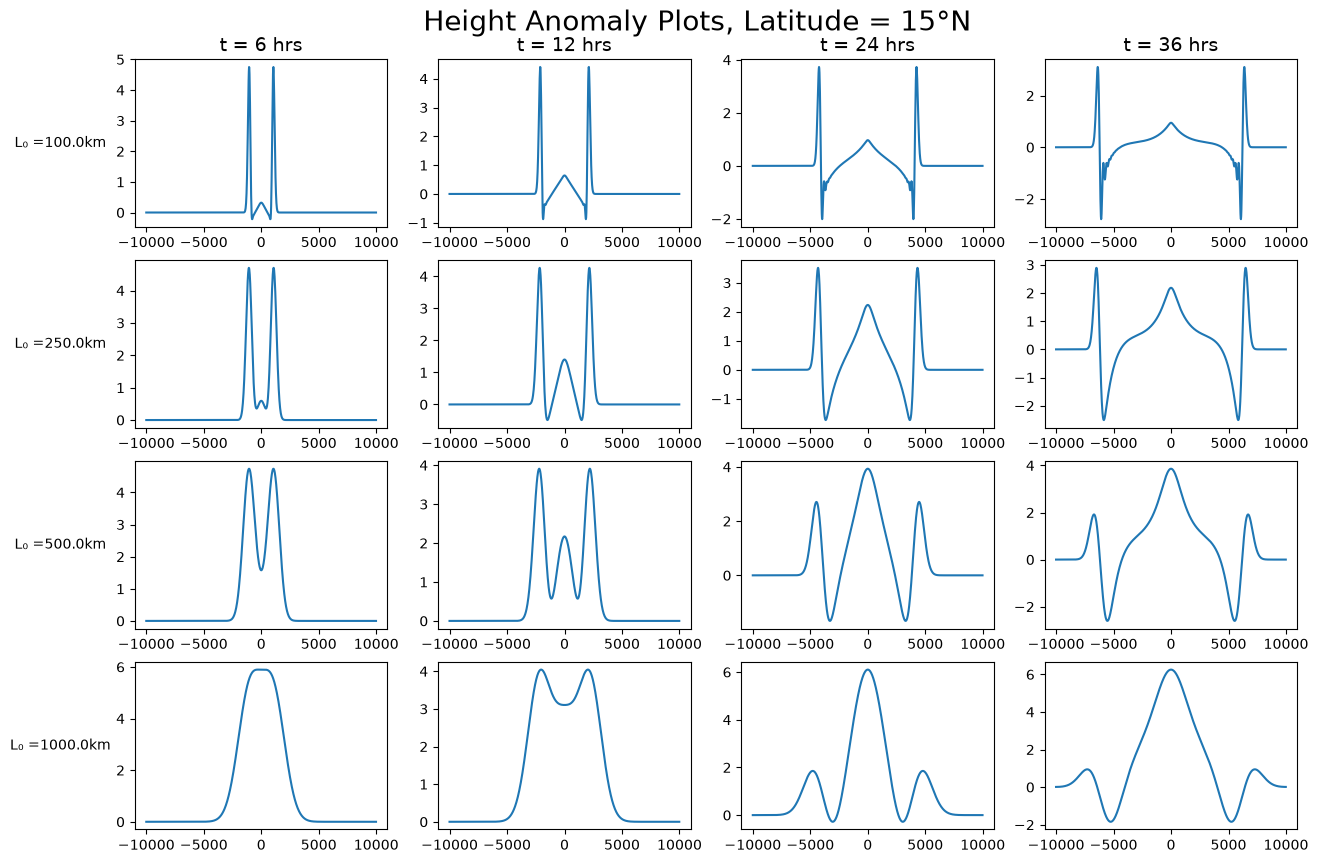

In [160]:
# 4 lats & 4 timesteps (6 hr, 12 hr, 24 hr, 36hr)

plt.figure()
fig, axes = plt.subplots(4, 4, figsize=(15, 10),sharex=False, sharey=False)

for case_index in list(range(0,4)):
    case=case_names[case_index+4]
    u=runs[case]["u"]
    v=runs[case]["v"]
    x=runs[case]["x"]
    h=runs[case]["h"]
    f_0=runs[case]["f_0"]
    l_0=runs[case]["width"]
    print(h.shape)
    time=runs[case]["time"]
    bs= axes[case_index,0].plot(x/1000,h[(6*6),:])
    axes[0,0].set_title("t = 6 hrs",fontsize=14)
    axes[0,1].set_title("t = 12 hrs",fontsize=14)
    axes[0,2].set_title("t = 24 hrs",fontsize=14)
    axes[0,3].set_title("t = 36 hrs",fontsize=14)
    lat=round(np.rad2deg(np.arcsin(f_0/(2*(OMEGA)))))
    axes[case_index,0].set_ylabel("L\u2080 ="+str(l_0/1000)+"km", rotation=0, labelpad=40, verticalalignment='center')
    bs= axes[case_index,1].plot(x/1000,h[(12*6),:])
    bs= axes[case_index,2].plot(x/1000,h[24*6,:])
    bs= axes[case_index,3].plot(x/1000,h[36*6,:])

plt.suptitle("Height Anomaly Plots, Latitude = 15°N", fontsize=20, y=0.93)

(289, 1000)
(289, 1000)
(289, 1000)
(289, 1000)


Text(0.5, 0.93, 'u wind Anomaly Plots, Latitude = 15°N')

<Figure size 640x480 with 0 Axes>

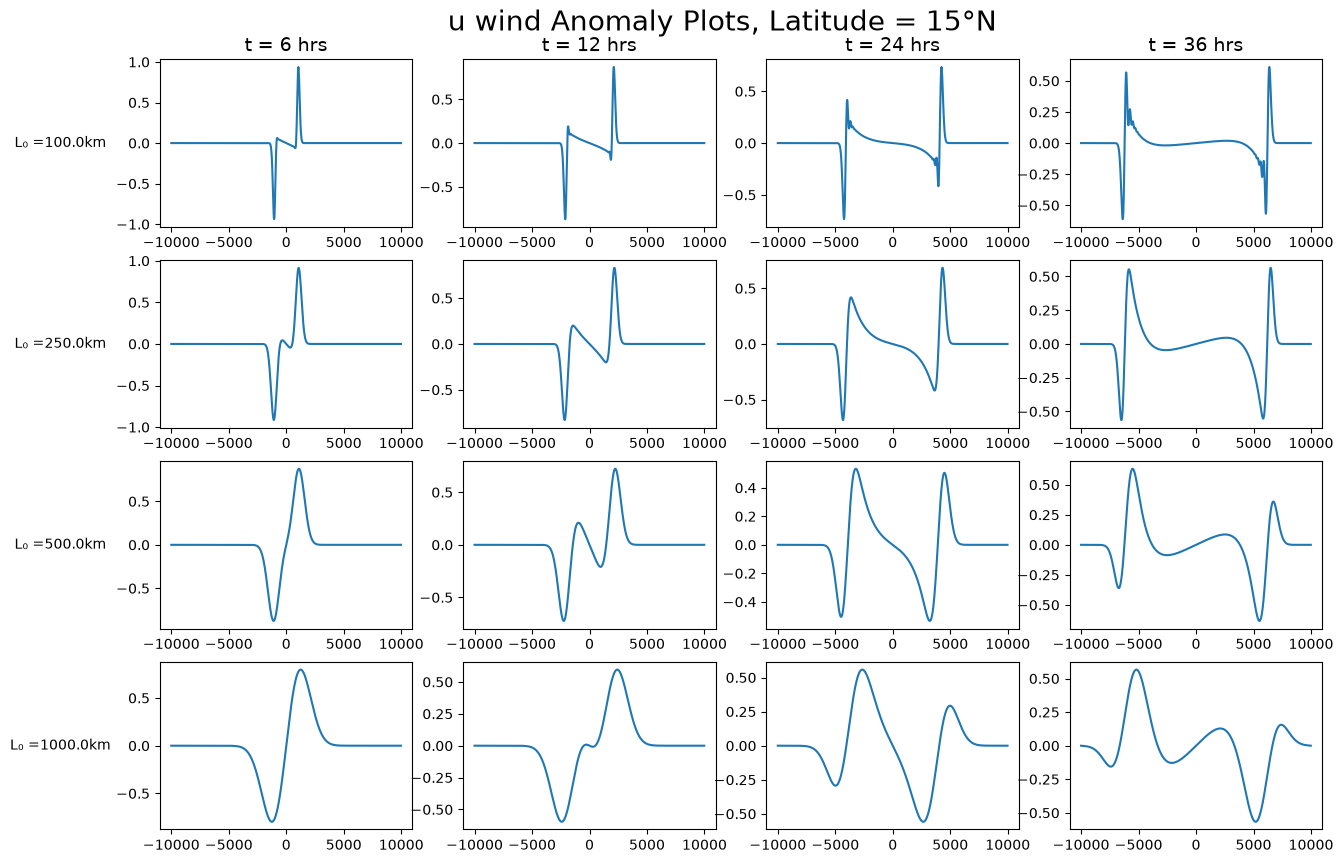

In [161]:
# 4 lats & 4 timesteps (6 hr, 12 hr, 24 hr, 36hr)

plt.figure()
fig, axes = plt.subplots(4, 4, figsize=(15, 10),sharex=False, sharey=False)

for case_index in list(range(0,4)):
    case=case_names[case_index+4]
    u=runs[case]["u"]
    v=runs[case]["v"]
    x=runs[case]["x"]
    h=runs[case]["h"]
    f_0=runs[case]["f_0"]
    l_0=runs[case]["width"]
    print(h.shape)
    time=runs[case]["time"]
    bs= axes[case_index,0].plot(x/1000,u[(6*6),:])
    axes[0,0].set_title("t = 6 hrs",fontsize=14)
    axes[0,1].set_title("t = 12 hrs",fontsize=14)
    axes[0,2].set_title("t = 24 hrs",fontsize=14)
    axes[0,3].set_title("t = 36 hrs",fontsize=14)
    lat=round(np.rad2deg(np.arcsin(f_0/(2*(OMEGA)))))
    axes[case_index,0].set_ylabel("L\u2080 ="+str(l_0/1000)+"km", rotation=0, labelpad=40, verticalalignment='center')
    bs= axes[case_index,1].plot(x/1000,u[(12*6),:])
    bs= axes[case_index,2].plot(x/1000,u[24*6,:])
    bs= axes[case_index,3].plot(x/1000,u[36*6,:])

plt.suptitle("u wind Anomaly Plots, Latitude = 15°N", fontsize=20, y=0.93)

(289, 1000)
(289, 1000)
(289, 1000)
(289, 1000)


Text(0.5, 0.93, 'v wind Anomaly Plots, Latitude = 15°N')

<Figure size 640x480 with 0 Axes>

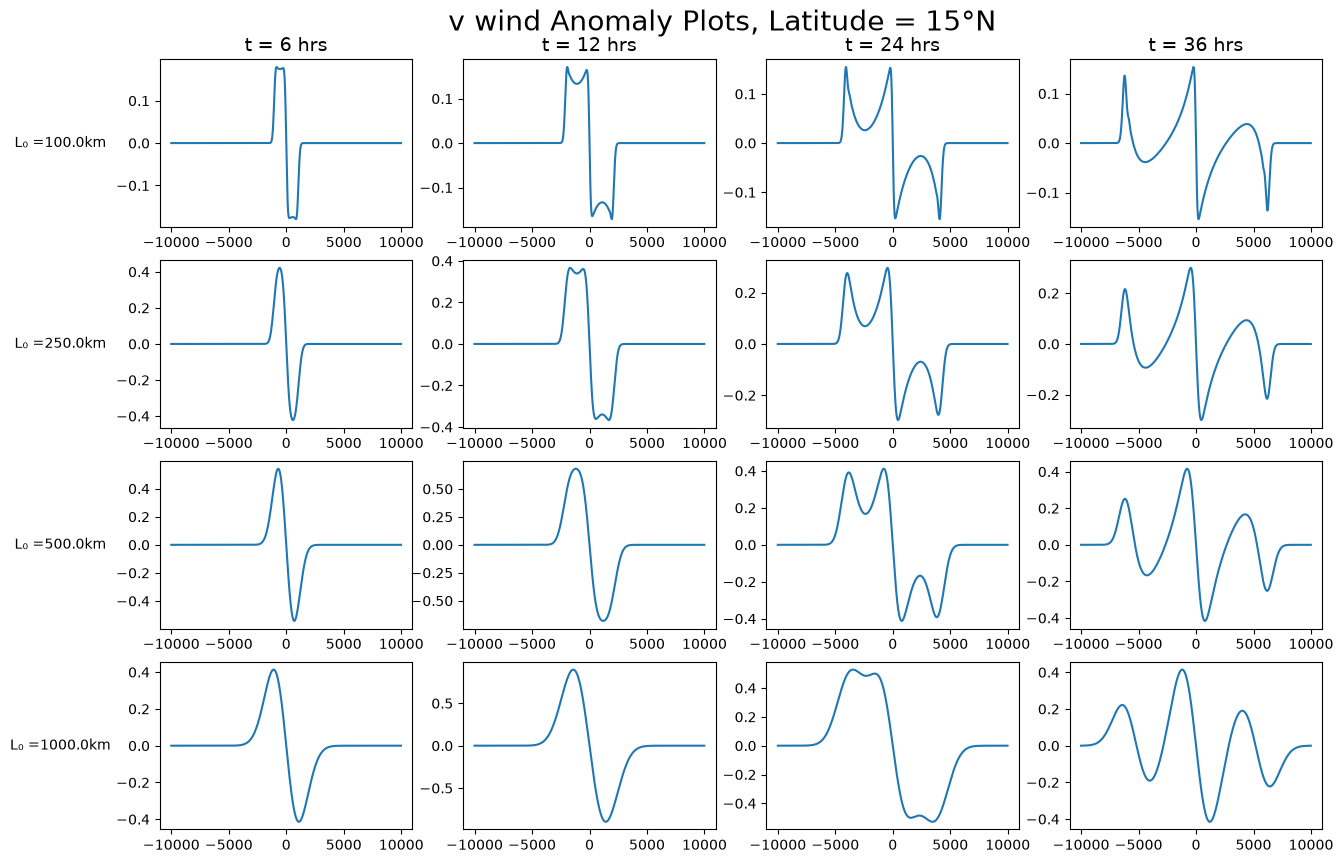

In [162]:
# 4 lats & 4 timesteps (6 hr, 12 hr, 24 hr, 36hr)

plt.figure()
fig, axes = plt.subplots(4, 4, figsize=(15, 10),sharex=False, sharey=False)

for case_index in list(range(0,4)):
    case=case_names[case_index+4]
    u=runs[case]["u"]
    v=runs[case]["v"]
    x=runs[case]["x"]
    h=runs[case]["h"]
    f_0=runs[case]["f_0"]
    l_0=runs[case]["width"]
    print(h.shape)
    time=runs[case]["time"]
    bs= axes[case_index,0].plot(x/1000,v[(6*6),:])
    axes[0,0].set_title("t = 6 hrs",fontsize=14)
    axes[0,1].set_title("t = 12 hrs",fontsize=14)
    axes[0,2].set_title("t = 24 hrs",fontsize=14)
    axes[0,3].set_title("t = 36 hrs",fontsize=14)
    lat=round(np.rad2deg(np.arcsin(f_0/(2*(OMEGA)))))
    axes[case_index,0].set_ylabel("L\u2080 ="+str(l_0/1000)+"km", rotation=0, labelpad=40, verticalalignment='center')
    bs= axes[case_index,1].plot(x/1000,v[(12*6),:])
    bs= axes[case_index,2].plot(x/1000,v[24*6,:])
    bs= axes[case_index,3].plot(x/1000,v[36*6,:])

plt.suptitle("v wind Anomaly Plots, Latitude = 15°N", fontsize=20, y=0.93)

In [46]:
# animations--> not used

#import glob
#from PIL import Image, ImageDraw

#bs=axes[0,0].pcolormesh(runs["15.0°N"]["x"]/1000,runs["15.0°N"]["time"],runs["15.0°N"]["u"],cmap="bwr")
#for t_step in list(range(len(runs["15.0°N"]["time"]))):
    #plt.figure()
    #fig, axes = plt.subplots(2, 2, figsize=(15, 10),sharex=False, sharey=False)
    #axes[0,0].set_ylim([-1, 1])
    #axes[0,1].set_ylim([-1, 1])
    #axes[1,0].set_ylim([-3, 6])
    #axes[1,0].set_xlabel('x (km)', fontsize=13)
    #axes[0,0].set_xlabel('x (km)', fontsize=13)
    #axes[0,1].set_xlabel('x (km)', fontsize=13)
    #axes[1,1].set_xlabel('x (km)', fontsize=13)
    #axes[0,0].set_ylabel('u velocity (m/s)', fontsize=13)
    #axes[0,1].set_ylabel('v velocity (m/s)', fontsize=13)
    #axes[1,0].set_ylabel('height perturbation (m)', fontsize=13)
    #bs=axes[0,0].plot(runs["15.0°N"]["x"]/1000,runs["15.0°N"]["u"][t_step,:],color="black",label=f"t={t_step}")
    #bs=axes[0,1].plot(runs["15.0°N"]["x"]/1000,runs["15.0°N"]["v"][t_step,:],color="black",label=f"t={t_step}")
    #bs=axes[1,0].plot(runs["15.0°N"]["x"]/1000,runs["15.0°N"]["h"][t_step,:],color="black",label=f"t={t_step}")
    #plt.suptitle('Time = ' + str(runs["15.0°N"]["time"][t_step]) + ' s', fontsize=15)
    #if runs["15.0°N"]["time"][t_step] < 100000.0 and runs["15.0°N"]["time"][t_step] >= 10000.0:
        #plt.savefig("./lab2/f_0_15_100km/" + "0" +str(runs["15.0°N"]["time"][t_step])+"s_plot"+".png")
        #plt.show()
    #elif runs["15.0°N"]["time"][t_step] >= 100000.0:
        #plt.savefig("./lab2/f_0_15_100km/" +str(runs["15.0°N"]["time"][t_step])+"s_plot"+".png")
    #else:
       # continue
    #plt.close(fig)
#fp_in = "./lab2/f_0_15_100km/*.png" 
#fp_out = "./lab2/f_0_15_100km/" + "f_0_15_100km_plot"+".gif"

#img, *imgs = [Image.open(f) for f in sorted(glob.glob(fp_in))]
#img.save(fp=fp_out, format='GIF', append_images=imgs, save_all=True, duration=200, loop=0)

# 6 plots with 4 subplts 


## Diagnostics

For each experiment, diagnose numerical values of $L_D$, $Bu$, and $Ro$ in a table or clearly labeled output. These will be useful for your interpretations below.
$$
L_D=\frac{\sqrt{gH}}{|f_0|},\qquad
Bu=\left(\frac{L_D}{L_0}\right)^2,\qquad
Ro=\frac{U}{|f_0|L_0},\qquad
U=\max_{x,t}\sqrt{u^2+v^2}.
$$
where $U$ is the maximum modeled speed over all saved positions and times; use consistent units in the calculations and be sure to label any units used as needed. Note that some of these metrics are invalid for $f_0=0$ (you can report NaN for those).

In [32]:
#testing pulling u/v components
#runs["15.0°N, L_0=500.0 km"]["u"][100,500]

np.float64(0.0)

In [163]:
#print(case_names)

#constants from above 
g=9.81                            # m/s^2
H = 250.0                        # base state layer depth, m

def ld_func(H_input,f0_input):
    if f0_input == 0:
        l_d=np.nan
    else:    
        l_d= np.sqrt(g*H_input)/(abs(f0_input))
    return(l_d)

def bu_func(ld_input,l0_input):
    b_u=(ld_input/l0_input)**2
    return(b_u)

def u_func(u_little,v_little, x_input,time_input):
    big_u_list=[]
    for i in range(len(time_input)):
        for j in range(len(x_input)):
            big_u_list.append(np.sqrt(u_little[i,j]**2+v_little[i,j]**2))
    return(max(big_u_list))
    
def r0_func(u_inp,f0_input,l0_input):
    if f0_input == 0:
        r_0=np.nan
    else:
        r_0=u_inp/(abs(f0_input)*l0_input)
    return(r_0)


for case in case_names:
    u=runs[case]["u"]
    v=runs[case]["v"]
    x=runs[case]["x"]
    h=runs[case]["h"]
    time=runs[case]["time"]
    f_0=runs[case]["f_0"]
    l_0=runs[case]["width"]
    print("For Case "+case)
    ld=ld_func(H,f_0)
    bu=bu_func(ld,l_0)
    big_u=u_func(u,v, x, time) 
    r_0=r0_func(big_u,f_0,l_0)
    print('L_D'+" = "+str(round(ld, 2))+' meters, B\u1D64'+" = "+str(round(bu, 2))+', Max Velocity'+" = "+str(round(big_u, 2))+' m/s, and R\u2080' +" = " +str(round(r_0, 2)))



For Case 0°N, L_0=500.0 km
L_D = nan meters, Bᵤ = nan, Max Velocity = 0.99 m/s, and R₀ = nan
For Case 15.0°N, L_0=500.0 km
L_D = 1311972.46 meters, Bᵤ = 6.89, Max Velocity = 0.98 m/s, and R₀ = 0.05
For Case 30.0°N, L_0=500.0 km
L_D = 679126.92 meters, Bᵤ = 1.84, Max Velocity = 0.98 m/s, and R₀ = 0.03
For Case 60.0°N, L_0=500.0 km
L_D = 392094.11 meters, Bᵤ = 0.61, Max Velocity = 0.96 m/s, and R₀ = 0.02
For Case 15.0°N, L_0=100 km
L_D = 1311972.46 meters, Bᵤ = 172.13, Max Velocity = 0.99 m/s, and R₀ = 0.26
For Case 15.0°N, L_0=250 km
L_D = 1311972.46 meters, Bᵤ = 27.54, Max Velocity = 0.99 m/s, and R₀ = 0.1
For Case 15.0°N, L_0=500 km
L_D = 1311972.46 meters, Bᵤ = 6.89, Max Velocity = 0.98 m/s, and R₀ = 0.05
For Case 15.0°N, L_0=1000 km
L_D = 1311972.46 meters, Bᵤ = 1.72, Max Velocity = 0.98 m/s, and R₀ = 0.03


## Interpretations

Address each of the following prompts in the markdown cell below them. In each response, be specific and reference your plots to support your points.

1. For a rotating experiment (i.e., $f_0 \ne 0$), describe the geostrophic adjustment process: explain what initiates motion, how the height and velocity fields subsequently evolve, and what evidence suggests that the central disturbance approaches geostrophic balance. Distinguish the central remnant from the outward-propagating waves.

In the geostrophic adjustment process, motion is initiated by an anomaly or perturbation, in this case, a 10m height anomaly. This anomaly creates an imbalance between the pressure gradient force and the Coriolis force, so the flow field attempts to reach geostrophic balance by altering the height and wind fields through a spectrum of inertial-gravity waves. When rotational effects (f0) dominate, we see non-propagating inertial oscillations dominate. The stronger the rotational effects, the stronger the Coriolis deflection, which helps the original anomaly remain centered. When rotational effects are negligible, we see gravity waves dominate. In this case, there would be little or no central remnant, and the majority of waves would propagate outwards (and the anomalies with them).

In our simulations with varying f0, we see higher latitudes associated with a stronger central remnant (i.e., non-propagating inertial oscillations) and fewer outward-propagating waves (i.e., gravity waves, Figure 1). We see this manifest in the wind field as well, with higher-latitude simulations having weaker u-wind anomalies. In the v-wind anomalies, we see higher values because the Coriolis deflection is stronger and rotational effects are larger at high latitudes. In contrast, the low-latitude simulations (e.g., 15°N) have higher-amplitude outward-propagating waves, higher u-wind anomalies associated with those propagating waves, and weaker v-wind anomalies.  

We can tell when the central disturbance has released geostrophic balance by looking at the wind and height fields. If geostrophic balance has been reached, the propagating waves (gravity waves) should haven weakened and thier assoicated anomaies should near zero. Gravity waves are a way for an out-of-balance system to redistribute energy; therefore, in geostrophic balance, there should not be gravity waves around the central remnant. 

2. Discuss the effects of changing $f_0$ and $L_0$ separately. What changes in the evolution and the remnant height anomaly at the center? Include the nonrotating case in your discussion. Incorporate $Ro$, $L_D$, and $Bu$ into your interpretations.


Changing f0:
When we increase the latitude, and therefore f0, we decrease the Burger Number (Bu). These changes are tied to the high f0. For latitude= 15°N, the Burger number is greater than 1, which indicates that rotation is not dominant. For latitude =60°N, the Burger number is less than 1, which means that rotational effects dominate. We see the Burger number manifest in the v-wind anomaly Hovmöller plots, with latitude= 15°N having weaker anomalies (and therefore weaker rotational effects) than latitude= 60°N (Figure 3). Additionally, stronger rotational effects (i.e., larger Coriolis deflection) support the persistence of the central remnant, as at latitude = 60°N (Figure 1). 

When f0 dominates, the Rossby radius of deformation (L_D) is small; this leads to slow gravity waves,  which manifest in the Hovmöller plots as weak u-wind anomalies outside of the central disturbance (Figure 2). For example, latitude = 30°N has stronger u-wind anomalies than latitude = 60°N. There appears to be slight decreases in maximum velocity (U) and Rossby number (R_0). However, these are not differences of notable magnitude (~0.05). The Rossby number (R_0) is still small for all latitudes, since L_0 is very large. This indicates that all cases should favor geostrophic balance.

A special case is when f0=0; we can expect no rotational effects and pure gravity waves, with fast propagation speeds. In the Hovmöller plots of height anomaly (Figure 1), we see no central disturbance, just the outward-propagating waves. Additionally, the u-wind anomalies remain high along with the propagating wave (Figure 2), and there are no v-wind anomalies (i.e., no rotation; Figure 3). 


Changing L0:
For a constant f_0 (at latitude = 15°N), L_D is constant, but still large, which indicates that gravity waves will propagate fast. We see this in the height and velocity fields as the anomalies propagate away from the center early in the simulations (Figures 5&6). The central anomaly weakens early in all simulations (Figure 5), but re-strengthens in simulations where L0 is large (e.g., L0 = 1000 km). 

The Burger number (B_u) is large for most simulations, which indicates that rotational effects are not very important in these simulations. The v-wind anomalies are extremely weak for L0 = 100 km and L0= 250 km (Figure 7). We don't see strong rotational effects until B_u nears 1 in the 
L0= 1000 km simulation (Figure 7). In this case, the depth scale nearly outweighs the large L_D. Since these rotational effects become stronger at larger length scales, it could contribute to the redevelopment of the central anomaly in large L0 simulations.

The Rossby number decreases as L0 increases. The Rossby number (R_0) is still small for all simulations, since L0 is very large. This indicates that all cases should favor geostrophic balance, except for L0= 100km. This could explain why the central anomaly begins to redevelop in the large L0 simulations (especially L0 = 1000 km; Figure 5). If the system is strongly tending towards geostrophic balance and rotational effects are large enough to have an impact, we can expect the Coriolis deflection to help form a central anomaly, like we see develop in L0=1000 km. 

Maximum velocity remains fairly constant; this is likely due to the strength of the velocity at the initial disturbance before the flow field has had much time to react to the perturbation. 

3. What's something surprising you learned or something you understand better now after this lab, either related to dynamics, modeling, or programming?

After completing this lab, I feel much more confident when coding with dictionaries! I have not used dictionaries in a few years because I have mostly worked with NETCDF files. I feel much more comfortable manipulating data within dictionaries now! This exercise was also a great refresher on Hovmöller diagrams. I loved using them in my undergraduate tropical class to look at outgoing longwave radiation (OLR) for the Madden-Julian Oscillation (MJO). It was interesting to look at Hovmöller charts in idealized simulations rather than observations! 

This lab really helped clarify the geostrophic adjustment process for me. I  knew the balance of forces the atmosphere was seeking, but I never looked at the waves related to geostrophic adjustment before. This definitely will change how I look at the synoptic-scale features in the atmosphere. Thanks for the super helpful lab!